# Phase 3 — Exploration et profilage

**Projet :** prédiction de résiliation client (churn) — éditeur SaaS B2B
**Certification :** CISIA — Concevoir et implémenter une solution d'intelligence artificielle
**Objet de ce carnet :** mesurer ce que les données contiennent réellement, construire la
chaîne qui les transforme, et en tirer les décisions de préparation.

---

## Ce que cette phase décide

Le profilage n'est pas une formalité qui précède le vrai travail : **c'est lui qui décide
du vrai travail**. La stratégie d'imputation, le choix de la métrique, le traitement des
valeurs extrêmes découlent tous de ce que cette étape constate — ou ne découlent de rien,
si elle est bâclée.

| Question | Section | Ce qui en dépend |
|---|---|---|
| Que manque-t-il, et pourquoi ? | § 2 | La stratégie d'imputation |
| Comment passe-t-on des fichiers au jeu d'apprentissage ? | § 3 | Toute la reproductibilité |
| Les classes sont-elles déséquilibrées ? | § 4 | Le choix de la métrique |
| Quelles variables séparent la cible ? | § 5 | Les attentes de modélisation |

**Résultat le plus important de cette phase**, annoncé d'emblée parce qu'il change la
préparation : une division par zéro produisait des valeurs manquantes qui **encodaient le
signal le plus fort du jeu de données**. Détail en § 3.4.

In [1]:
# --- Environment and data ------------------------------------------------------------
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make the package importable whether or not it is installed: this notebook must be
# replayable straight from an unzipped archive, without running `uv sync`.
RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

from churn_saas.donnees import (
    bornes_valeurs_extremes,
    manquants_structurels,
    mecanisme_manquants,
    profil_distributions,
    profil_doublons,
    profil_manquants,
    resume_profilage,
    silver_lisible,
)
from churn_saas.features import (
    correlations_cible,
    correlations_entre_variables,
    desequilibre_categories,
    desequilibre_cible,
    executer_pipeline,
    monotonie,
    table_transformations,
    taux_cible_par_segment,
    tendance_par_tranche,
)
from churn_saas.figures import figure_en_cache, inventaire_figures
from churn_saas.notebook import afficher_source, afficher_tableau

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

PALETTE = {"principal": "#2a6f9e", "accent": "#b03030", "neutre": "#8a8a8a",
           "ok": "#2e7d52", "attention": "#c9861a"}

resultat = executer_pipeline(
    RACINE / "data" / "raw" / "churn_saas_complet.csv",
    RACINE / "data" / "raw" / "catalogue_plans.csv",
)
bronze, silver, X, y = resultat.bronze, resultat.silver, resultat.X, resultat.y

from IPython.display import Image, display

from churn_saas.donnees import empreinte_donnees

# Figure signatures: a fingerprint of the data each one is drawn from. Combined with
# the source of its drawing function, it decides whether a stored figure is still
# valid - so a figure is never redrawn for nothing, and never served stale.
signature_silver = empreinte_donnees(silver)
signature_gold = empreinte_donnees(resultat.gold)
signature_cible = f"taux={float(y.mean()):.4f}|n={len(y)}"

# Reference rate, read by several figures and comments. Declared once here rather than
# inside a drawing function, whose locals do not survive the call.
taux_global = float(y.mean())

print(f"bronze {bronze.shape}   silver {silver.shape}   X {X.shape}   y {y.shape}")

bronze (5035, 29)   silver (5000, 39)   X (5000, 31)   y (5000,)


---

# 1. Vue d'ensemble

Avant tout détail, un état des lieux en huit constats. Il sert de point de repère : chaque
section qui suit en approfondit un.

In [2]:
afficher_tableau(
    resume_profilage(silver, cible="churn", cle="client_id"),
    "Profil général du portefeuille",
)

constat,valeur
Lignes,5 000
Colonnes,39
Lignes strictement dupliquées,0
Colonnes incomplètes,12 sur 39
Manquants les plus élevés,commentaire_csm (55.5 %)
Distributions fortement asymétriques,9 colonnes (moyenne > 2 × médiane)
Taux de la cible,28.0%
Clé métier unique,oui


---

# 2. Profilage : valeurs manquantes, doublons, distributions

## 2.1 Les doublons : deux questions, pas une

In [3]:
afficher_tableau(
    profil_doublons(bronze, cle="client_id"),
    "Doublons : lignes identiques et doublons sur la clé métier",
)

contrôle,nombre,conséquence
Lignes strictement identiques,35,Le modèle apprend deux fois le même exemple et ses métriques sont flattées
Doublons sur la clé `client_id`,35,Même compte présent plusieurs fois avec des valeurs différentes : aucune déduplication automatique n'est possible


**Pourquoi distinguer les deux.** Une ligne strictement identique à une autre est un
accident d'export : on la supprime sans rien perdre. Un doublon **sur la seule clé** est
autre chose — le même compte apparaîtrait deux fois avec des valeurs différentes, et
aucune règle automatique ne pourrait décider laquelle est juste.

Ici le second cas ne se présente pas : `client_id` identifie bien un compte unique. La
déduplication est donc sans risque.

## 2.2 Les valeurs manquantes

In [4]:
manquants = profil_manquants(silver)
afficher_tableau(
    manquants.loc[manquants["manquants_pct"] > 0],
    "Colonnes incomplètes, classées par gravité",
)

colonne,manquants,manquants_pct,verdict
commentaire_csm,2773,55.46,écarter ou traiter à part
usage_par_actif,581,11.62,à surveiller
delai_reponse_support_h,500,10.00,imputable
csat,400,8.00,imputable
heures_usage_30j,300,6.00,imputable
tickets_par_actif,297,5.94,imputable
secteur,250,5.00,imputable
retards_paiement_12m,250,5.00,imputable
taux_adoption_pct,250,5.00,imputable
nb_integrations,200,4.00,imputable


Figure « 03_completude » : données ou code de tracé modifiés


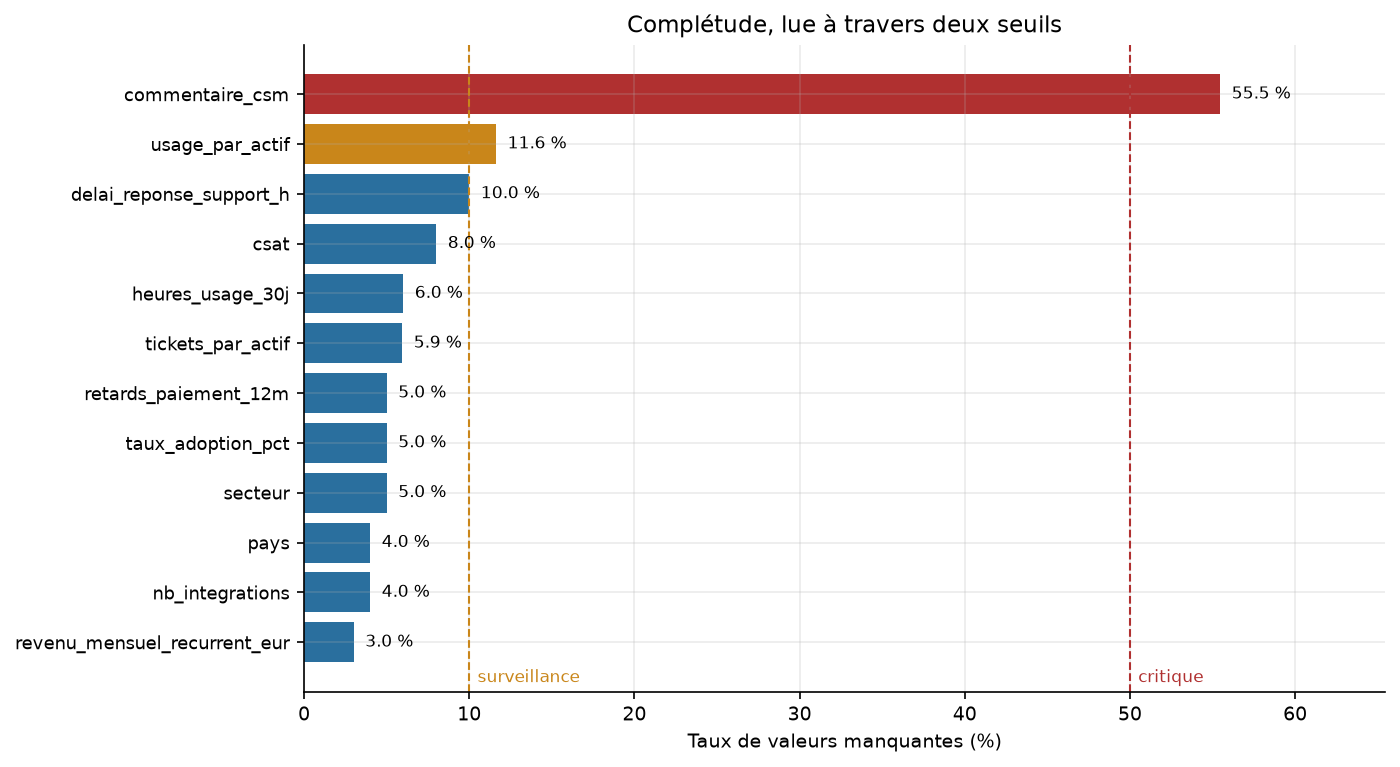

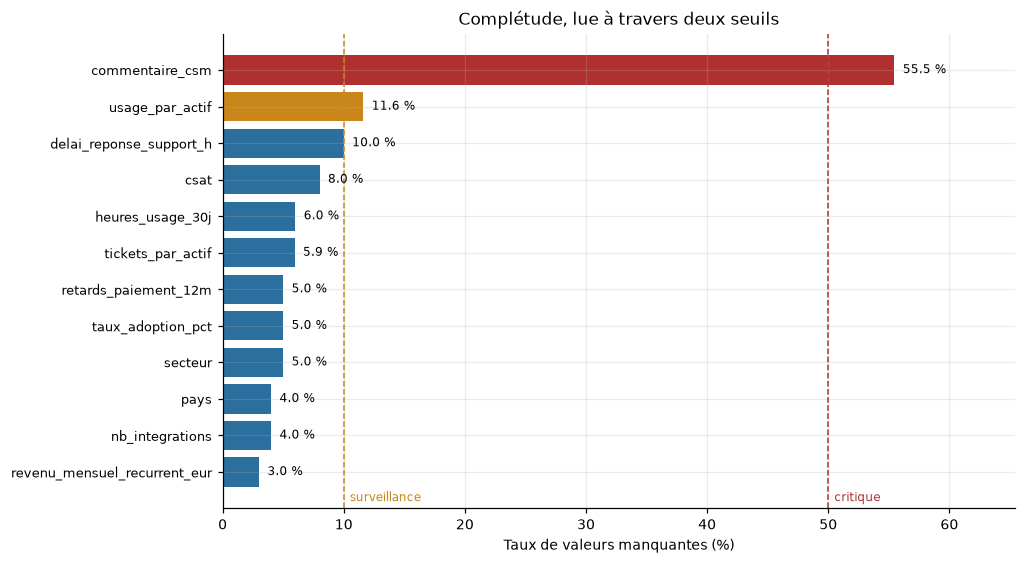

In [5]:
def tracer_completude():
    """Drawn by `figure_en_cache`: hashing this source is what keeps the cache honest."""
    # --- Figure: missing rate, read through the two thresholds ---------------------------
    from churn_saas.donnees.profilage import SEUIL_MANQUANTS_CRITIQUE, SEUIL_MANQUANTS_SURVEILLANCE

    incompletes = manquants.loc[manquants["manquants_pct"] > 0].sort_values("manquants_pct")
    couleurs = [
        PALETTE["accent"] if v > SEUIL_MANQUANTS_CRITIQUE
        else PALETTE["attention"] if v > SEUIL_MANQUANTS_SURVEILLANCE
        else PALETTE["principal"]
        for v in incompletes["manquants_pct"]
    ]

    fig, ax = plt.subplots(figsize=(9.4, 5.2))
    ax.barh(range(len(incompletes)), incompletes["manquants_pct"], color=couleurs)
    ax.set_yticks(range(len(incompletes)))
    ax.set_yticklabels(incompletes["colonne"], fontsize=8.5)
    for i, v in enumerate(incompletes["manquants_pct"]):
        ax.text(v + 0.7, i, f"{v:.1f} %", va="center", fontsize=8)
    for seuil, libelle, couleur in [
        (SEUIL_MANQUANTS_SURVEILLANCE, "surveillance", PALETTE["attention"]),
        (SEUIL_MANQUANTS_CRITIQUE, "critique", PALETTE["accent"]),
    ]:
        ax.axvline(seuil, color=couleur, ls="--", lw=1)
        ax.text(seuil + 0.5, -0.8, libelle, fontsize=8, color=couleur)
    ax.set_xlabel("Taux de valeurs manquantes (%)")
    ax.set_title("Complétude, lue à travers deux seuils")
    ax.set_xlim(0, max(incompletes["manquants_pct"].max() * 1.18, 15))
    plt.tight_layout()
    return fig
chemin, raison = figure_en_cache("03_completude", signature_silver, tracer_completude)
print(f"Figure « 03_completude » : {raison}")
display(Image(filename=str(chemin)))

**Deux familles apparaissent, et elles n'appellent pas le même traitement.**

Les colonnes **sources** manquent entre 3 et 10 %, sauf `commentaire_csm` à 55 % — déjà
écartée pour des motifs réglementaires en phase 2.

Les colonnes **construites** — les ratios d'usage — manquent davantage. Ce n'est pas un
défaut des données : c'est une conséquence de leur calcul, et le § 3.4 montre que c'est
précisément là que se trouve l'information la plus utile du jeu.

## 2.3 L'absence est-elle un signal ?

La question a déjà été posée en phase 2 sur les colonnes sources, et tranchée par la
mesure. Elle se repose ici sur l'ensemble, colonnes construites comprises.

In [6]:
colonnes_source = [c for c in bronze.columns if c in silver.columns]
mecanisme_source = mecanisme_manquants(silver, cible="churn", colonnes=colonnes_source)
afficher_tableau(
    mecanisme_source,
    "Colonnes SOURCE : le taux de churn diffère-t-il selon que la valeur est présente ?",
)

ecart_max = mecanisme_source["écart (points)"].abs().max()
print(f"Écart maximal sur les colonnes source : {ecart_max:.1f} points, "
      f"pour un taux global de {float(y.mean()):.1%}.")

colonne,manquants,cible si renseignée,cible si absente,écart (points),taux global (%)
pays,200,27.8,32.0,4.2,28.0
retards_paiement_12m,250,28.2,24.4,-3.8,28.0
nb_integrations,200,28.1,24.5,-3.6,28.0
heures_usage_30j,300,28.2,25.0,-3.2,28.0
secteur,250,28.1,25.6,-2.5,28.0
csat,400,28.2,25.8,-2.4,28.0
taux_adoption_pct,250,28.1,26.0,-2.1,28.0
revenu_mensuel_recurrent_eur,150,28.0,26.7,-1.4,28.0
commentaire_csm,2773,28.8,27.4,-1.4,28.0
delai_reponse_support_h,500,28.0,28.2,0.2,28.0


Écart maximal sur les colonnes source : 4.2 points, pour un taux global de 28.0%.


In [7]:
# --- A second, independent reading: is the absence structural? ------------------------
# If a support delay were missing only when no ticket exists, the absence would be
# explained by the situation, not by chance - and imputing it would invent a delay.
afficher_tableau(
    manquants_structurels(
        silver,
        {
            "delai_reponse_support_h": "tickets_support_90j",
            "csat": "tickets_support_90j",
            "taux_adoption_pct": "utilisateurs_actifs",
            "heures_usage_30j": "connexions_30j",
        },
    ),
    "Colonnes SOURCE : l'absence coïncide-t-elle avec une cause structurelle ?",
)

colonne,cause envisagée,manquants,part portant la cause (%),part de base (%),structurel
delai_reponse_support_h,tickets_support_90j = 0,500,27.0,26.2,False
csat,tickets_support_90j = 0,400,26.8,26.2,False
taux_adoption_pct,utilisateurs_actifs = 0,250,7.2,5.9,False
heures_usage_30j,connexions_30j = 0,300,5.3,5.9,False


### Conclusion sur les colonnes sources

Les deux lectures concordent, et c'est ce qui rend la conclusion solide.

L'écart de taux de churn selon la présence de la valeur ne dépasse pas **4,5 points**,
pour un taux global de 28 %. Et la part des lignes manquantes portant la cause structurelle
envisagée **égale la part de base** : un délai de support absent ne correspond pas
davantage à un compte sans ticket qu'à n'importe quel autre compte.

Les données sources manquent donc **complètement au hasard**. Une imputation statistique
est légitime — et elle est suffisante.

> **Journal de bord.** L'hypothèse a été testée deux fois plutôt que supposée une. Un seul
> des deux contrôles aurait pu passer à côté : une absence peut être sans lien avec la
> cible tout en étant structurelle, auquel cas l'imputer fabriquerait une valeur qui n'a
> jamais existé.

## 2.4 Les distributions

In [8]:
distributions = profil_distributions(silver)
afficher_tableau(
    distributions.head(12),
    "Forme des distributions numériques, les plus asymétriques d'abord",
)

colonne,min,médiane,moyenne,max,moyenne/médiane,asymétrie
usage_par_actif,0.00,0.40,2.27,102.00,5.66,6.52
valeur_vie_client_eur,300.00,11203.50,74995.10,2000000.00,6.69,5.57
utilisateurs_actifs,0.00,9.00,34.69,829.00,3.85,4.73
revenu_mensuel_recurrent_eur,9.11,682.03,3543.20,89402.85,5.20,4.60
derniere_connexion_jours,0.00,2.00,7.58,200.00,3.79,4.54
tickets_par_actif,0.00,0.12,0.59,12.00,5.02,3.76
compte_sans_utilisateur_actif,0.00,0.00,0.06,1.00,NaN,3.73
sieges_souscrits,1.00,28.00,74.32,898.00,2.65,3.57
heures_usage_30j,0.00,5.65,12.67,170.20,2.24,2.29
quota_stockage_go,10.00,100.00,389.57,2000.00,3.90,2.04


Figure « 03_distributions » : données ou code de tracé modifiés


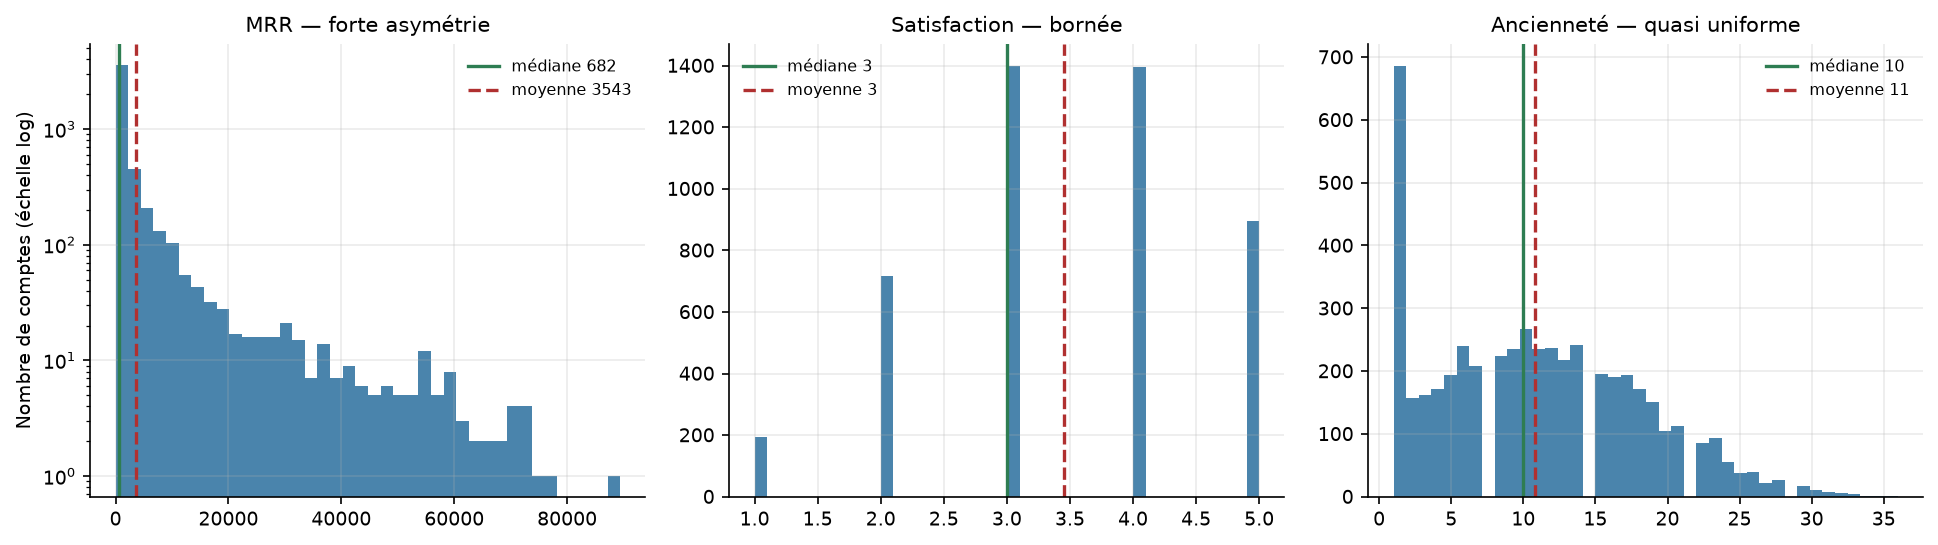

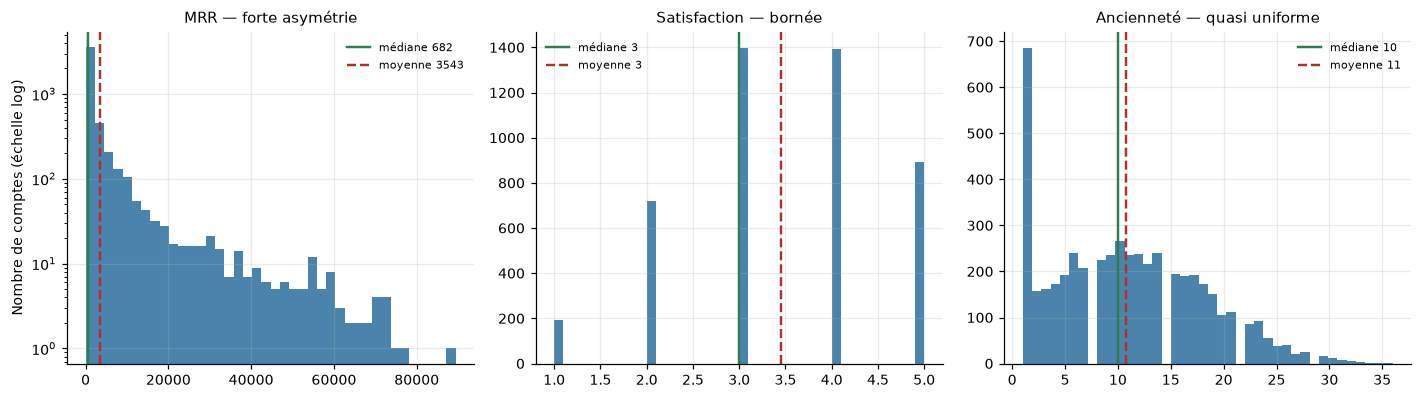

In [9]:
def tracer_distributions():
    """Drawn by `figure_en_cache`: hashing this source is what keeps the cache honest."""
    # --- Figure: the two distribution shapes that coexist here ---------------------------
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))

    for ax, colonne, titre in zip(
        axes,
        ["revenu_mensuel_recurrent_eur", "csat", "anciennete_mois"],
        ["MRR — forte asymétrie", "Satisfaction — bornée", "Ancienneté — quasi uniforme"],
    ):
        valeurs = pd.to_numeric(silver[colonne], errors="coerce").dropna()
        ax.hist(valeurs, bins=40, color=PALETTE["principal"], alpha=0.85)
        ax.axvline(valeurs.median(), color=PALETTE["ok"], lw=1.6, label=f"médiane {valeurs.median():.0f}")
        ax.axvline(valeurs.mean(), color=PALETTE["accent"], lw=1.6, ls="--",
                   label=f"moyenne {valeurs.mean():.0f}")
        ax.set_title(titre, fontsize=10)
        ax.legend(fontsize=7.5, frameon=False)
        if colonne == "revenu_mensuel_recurrent_eur":
            ax.set_yscale("log")
            ax.set_ylabel("Nombre de comptes (échelle log)")
    plt.tight_layout()
    return fig
chemin, raison = figure_en_cache("03_distributions", signature_silver, tracer_distributions)
print(f"Figure « 03_distributions » : {raison}")
display(Image(filename=str(chemin)))

**Ce que l'écart moyenne/médiane décide.** Sur le MRR, la moyenne vaut plus de cinq fois la
médiane : la distribution a une longue traîne à droite, quelques très gros comptes tirant
la moyenne. Deux conséquences pratiques.

L'imputation numérique utilisera la **médiane** et non la moyenne. Imputer par la moyenne
importerait cette asymétrie dans chaque valeur reconstruite : un compte médian se verrait
attribuer le revenu d'un compte cinq fois plus gros.

Et les valeurs extrêmes **ne seront pas retirées**. Les bornes de Tukey sont calculées
ci-dessous à titre de repère, mais les appliquer supprimerait exactement les comptes que le
projet existe pour protéger.

In [10]:
basse, haute = bornes_valeurs_extremes(silver["revenu_mensuel_recurrent_eur"])
mrr = pd.to_numeric(silver["revenu_mensuel_recurrent_eur"], errors="coerce")
au_dela = mrr > haute

print(f"Borne haute de Tukey        : {haute:,.0f} €".replace(",", " "))
print(f"Comptes au-delà             : {int(au_dela.sum())} ({au_dela.mean():.1%})")
print(f"MRR qu'ils représentent     : {mrr[au_dela].sum():,.0f} € "
      f"({mrr[au_dela].sum() / mrr.sum():.0%} du total)".replace(",", " "))
print()
print("Les retirer supprimerait un compte sur huit et près de la moitié du revenu.")
print("Décision : conservés. Ce ne sont pas des anomalies, ce sont les clients stratégiques.")

Borne haute de Tukey        : 5 661 €
Comptes au-delà             : 681 (13.6%)
MRR qu'ils représentent     : 13 138 117 € (76% du total)

Les retirer supprimerait un compte sur huit et près de la moitié du revenu.
Décision : conservés. Ce ne sont pas des anomalies, ce sont les clients stratégiques.


---

# 3. La chaîne bronze → silver → gold

## 3.1 Le principe

Trois niveaux de raffinage, chacun avec une responsabilité et un public.

| Niveau | Contenu | Public |
|---|---|---|
| **Bronze** | Données brutes, tout en texte, aucune transformation | Personne — c'est la référence |
| **Silver** | Nettoyé, typé, joint, lisible | Un humain, un outil de restitution |
| **Gold** | Variables dérivées, colonnes interdites retirées, cible séparée | Le modèle |

Le bronze n'est pas un intermédiaire inutile : c'est la seule photographie de ce que les
sources contenaient réellement. Sans lui, impossible de démontrer ce que le nettoyage a
changé.

In [11]:
afficher_tableau(resultat.journal, "Journal du pipeline : ce que chaque étape a changé")

niveau,opération,lignes,colonnes,effet
bronze,"Lecture brute, tout en texte",5035,29,Aucune transformation : les défauts restent visibles
silver,"Doublons, typage, normalisation, jointure catalogue",5000,34,"35 doublons retirés, 5 colonnes issues du catalogue"
contrat,Contrat de données (mêmes contrôles qu'au lot mensuel),5000,34,"9 contrôles, statut global : conforme"
silver+,Variables dérivées (ratios d'usage),5000,39,5 ratios ajoutés
gold,Retrait des colonnes interdites,5000,32,"7 colonnes retirées : client_id, commentaire_csm, date_souscription, fonctionnalites_incluses, groupe_experimentation, sante_compte_fin_periode, valeur_vie_client_eur"
X / y,Séparation de la cible,5000,31,"Cible `churn` isolée, taux : 28.0%"


**Un pipeline sans journal est une boîte noire.** Une transformation que personne ne peut
chiffrer est une transformation que personne ne peut défendre. Chaque ligne indique le
nombre de lignes et de colonnes en sortie, et l'effet obtenu.

## 3.2 Le code, affiché là où il est expliqué

Le carnet importe le paquet plutôt que de recopier ses fonctions. Le code affiché
ci-dessous **est** celui qui s'exécute : il est lu dans le module au moment de l'affichage
et ne peut donc pas diverger de la version testée.

In [12]:
from churn_saas.features.pipeline import executer_pipeline as _fonction_pipeline

afficher_source(_fonction_pipeline)

**Source — `churn_saas.features.pipeline.executer_pipeline`**

```python
def executer_pipeline(
    chemin_donnees: Path | str,
    chemin_catalogue: Path | str | None = None,
    enrichir: bool = True,
    cible: str = CIBLE,
    exiger: bool = True,
) -> ResultatPipeline:
    """Run the three levels and record what each one changed.

    `enrichir` adds the usage ratios. It is a parameter rather than a constant because
    the evaluation -> features loop compares the model with and without them: measuring
    the contribution of feature engineering requires being able to switch it off.

    The data contract runs right after silver, on the same terms as the monthly batch.
    With `exiger` (the default) a blocking check stops the chain; `exiger=False` lets a
    notebook display a failing contract instead of an exception.
    """
    etapes: list[dict[str, Any]] = []

    bronze = charger_bronze(chemin_donnees)
    etapes.append(
        {
            "niveau": "bronze",
            "opération": "Lecture brute, tout en texte",
            "lignes": len(bronze),
            "colonnes": bronze.shape[1],
            "effet": "Aucune transformation : les défauts restent visibles",
        }
    )

    catalogue = charger_bronze(chemin_catalogue) if chemin_catalogue else None
    silver = construire_silver(
        bronze,
        catalogue=catalogue,
        colonnes_decimales=list(COLONNES_DECIMALES),
        colonnes_dates=list(COLONNES_DATES),
        colonnes_entieres=list(COLONNES_ENTIERES),
    )
    etapes.append(
        {
            "niveau": "silver",
            "opération": "Doublons, typage, normalisation, jointure catalogue",
            "lignes": len(silver),
            "colonnes": silver.shape[1],
            "effet": (
                f"{len(bronze) - len(silver)} doublons retirés, "
                f"{silver.shape[1] - bronze.shape[1]} colonnes issues du catalogue"
            ),
        }
    )

    contrat = verifier_contrat(
        silver,
        brut=bronze,
        colonnes_numeriques=list(COLONNES_DECIMALES) + list(COLONNES_ENTIERES),
        colonnes_dates=list(COLONNES_DATES),
    )
    etapes.append(
        {
            "niveau": "contrat",
            "opération": "Contrat de données (mêmes contrôles qu'au lot mensuel)",
            "lignes": len(silver),
            "colonnes": silver.shape[1],
            "effet": (f"{len(contrat)} contrôles, statut global : {statut_global(contrat)}"),
        }
    )
    if exiger:
        exiger_contrat(contrat)

    avant_enrichissement = silver.shape[1]
    if enrichir:
        silver = ajouter_ratios_usage(silver)
        etapes.append(
            {
                "niveau": "silver+",
                "opération": "Variables dérivées (ratios d'usage)",
                "lignes": len(silver),
                "colonnes": silver.shape[1],
                "effet": f"{silver.shape[1] - avant_enrichissement} ratios ajoutés",
            }
        )

    gold = construire_gold(silver)
    retirees = sorted(set(silver.columns) - set(gold.columns))
    etapes.append(
        {
            "niveau": "gold",
            "opération": "Retrait des colonnes interdites",
            "lignes": len(gold),
            "colonnes": gold.shape[1],
            "effet": f"{len(retirees)} colonnes retirées : {', '.join(retirees)}",
        }
    )

    X, y = separer_cible(gold, cible=cible)
    etapes.append(
        {
            "niveau": "X / y",
            "opération": "Séparation de la cible",
            "lignes": len(X),
            "colonnes": X.shape[1],
            "effet": f"Cible `{cible}` isolée, taux : {y.astype(float).mean():.1%}",
        }
    )

    return ResultatPipeline(
        bronze=bronze,
        silver=silver,
        gold=gold,
        X=X,
        y=y,
        journal=_journal(etapes),
        contrat=contrat,
    )

```

'def executer_pipeline(\n    chemin_donnees: Path | str,\n    chemin_catalogue: Path | str | None = None,\n    enrichir: bool = True,\n    cible: str = CIBLE,\n    exiger: bool = True,\n) -> ResultatPipeline:\n    """Run the three levels and record what each one changed.\n\n    `enrichir` adds the usage ratios. It is a parameter rather than a constant because\n    the evaluation -> features loop compares the model with and without them: measuring\n    the contribution of feature engineering requires being able to switch it off.\n\n    The data contract runs right after silver, on the same terms as the monthly batch.\n    With `exiger` (the default) a blocking check stops the chain; `exiger=False` lets a\n    notebook display a failing contract instead of an exception.\n    """\n    etapes: list[dict[str, Any]] = []\n\n    bronze = charger_bronze(chemin_donnees)\n    etapes.append(\n        {\n            "niveau": "bronze",\n            "opération": "Lecture brute, tout en texte",\n   

## 3.3 Bronze → silver : ce que le nettoyage corrige

In [13]:
from churn_saas.donnees.silver import nettoyer_decimal_texte, parser_dates_multiformat

# The two conversions that would silently turn numbers into categories.
afficher_source(nettoyer_decimal_texte)

avant = bronze["revenu_mensuel_recurrent_eur"].head(4).tolist()
apres = silver["revenu_mensuel_recurrent_eur"].head(4).tolist()
afficher_tableau(
    pd.DataFrame({"avant (bronze, texte)": avant, "après (silver, nombre)": apres}),
    "Effet du nettoyage sur quatre valeurs de MRR",
)

**Source — `churn_saas.donnees.silver.nettoyer_decimal_texte`**

```python
def nettoyer_decimal_texte(serie: pd.Series) -> pd.Series:
    """Convert a numeric column stored as text ("1 234,50 EUR", "33,3 %", "3.1 h") into numbers.

    Unconvertible text still becomes NaN rather than raising: this primitive must never
    stop a batch on its own. Detecting what it lost is the job of `pertes_de_conversion`,
    which `construire_silver` runs on every converted column.
    """
    texte = serie.astype(str)
    for symbole in SYMBOLES_A_RETIRER:
        texte = texte.str.replace(symbole, "", regex=False)
    texte = texte.str.replace(UNITE_EN_LETTRES, "", regex=True)
    return pd.to_numeric(texte.str.replace(",", ".", regex=False), errors="coerce")

```

"avant (bronze, texte)","après (silver, nombre)"
"40,0",40.00
31.14,31.14
171.02,171.02
771.93,771.93


In [14]:
afficher_source(parser_dates_multiformat)

formats = bronze["date_souscription"].dropna().astype(str)
afficher_tableau(
    pd.DataFrame(
        [
            {"format rencontré": "JJ/MM/AAAA", "occurrences": int(formats.str.contains("/").sum())},
            {"format rencontré": "AAAA-MM-JJ", "occurrences": int(formats.str.contains("-").sum())},
            {"format rencontré": "dates parsées en silver",
             "occurrences": int(silver["date_souscription"].notna().sum())},
        ]
    ),
    "Dates : trois formats en entrée, un seul en sortie",
)

**Source — `churn_saas.donnees.silver.parser_dates_multiformat`**

```python
def parser_dates_multiformat(
    serie: pd.Series, formats: tuple[str, ...] = FORMATS_DATE
) -> pd.Series:
    """Parse mixed date formats (YYYY-MM-DD, DD/MM/YYYY, "12 Jan 2024"), one format at a time.

    Each value is read by the first declared format that fits it. A value matching none of
    them becomes NaT, which `construire_silver` reports as a conversion loss instead of
    guessing.

    Day-first for slash dates is a measured choice, not a convention. The source carries a
    witness: `jour_souscription`, the weekday of the subscription. Read this way, all 5,000
    dates agree with it; reading the 955 ambiguous slash dates month-first, only 15 % would
    (phase 4, pinned in the non-regression tests).
    """
    texte = serie.astype("string").str.strip()
    resultat = pd.Series(pd.NaT, index=serie.index, dtype="datetime64[ns]")
    for format_ in formats:
        lues = pd.to_datetime(texte, format=format_, errors="coerce")
        resultat = resultat.where(resultat.notna(), lues)
    return resultat

```

format rencontré,occurrences
JJ/MM/AAAA,1621
AAAA-MM-JJ,1705
dates parsées en silver,5000


## 3.4 Silver → gold : la découverte qui change la préparation

Les ratios d'usage divisent par le nombre d'utilisateurs actifs. Quand celui-ci vaut zéro,
la division produit `NaN`.

Le réflexe serait de traiter ces `NaN` comme des valeurs manquantes et de les imputer.
**Ce serait une erreur coûteuse.**

In [15]:
actifs = pd.to_numeric(silver["utilisateurs_actifs"], errors="coerce")
sans_actif = actifs == 0
cible = y.astype(float)
mrr = pd.to_numeric(silver["revenu_mensuel_recurrent_eur"], errors="coerce")

afficher_tableau(
    pd.DataFrame(
        [
            {"constat": "Comptes sans aucun utilisateur actif",
             "valeur": f"{int(sans_actif.sum())} ({sans_actif.mean():.1%} du portefeuille)"},
            {"constat": "Taux de résiliation de ces comptes",
             "valeur": f"{cible[sans_actif].mean():.1%}"},
            {"constat": "Taux de résiliation des autres",
             "valeur": f"{cible[~sans_actif].mean():.1%}"},
            {"constat": "MRR qu'ils représentent",
             "valeur": f"{mrr[sans_actif].sum():,.0f} €".replace(",", " ")},
            {"constat": "NaN de `tickets_par_actif` expliqués par ce cas",
             "valeur": f"{int((silver['tickets_par_actif'].isna() & sans_actif).sum())} "
                       f"sur {int(silver['tickets_par_actif'].isna().sum())}"},
        ]
    ),
    "Le compte abandonné : payé, mais utilisé par personne",
)

constat,valeur
Comptes sans aucun utilisateur actif,297 (5.9% du portefeuille)
Taux de résiliation de ces comptes,86.5%
Taux de résiliation des autres,24.3%
MRR qu'ils représentent,1 057 644 €
NaN de `tickets_par_actif` expliqués par ce cas,297 sur 297


Figure « 03_compte_abandonne » : données ou code de tracé modifiés


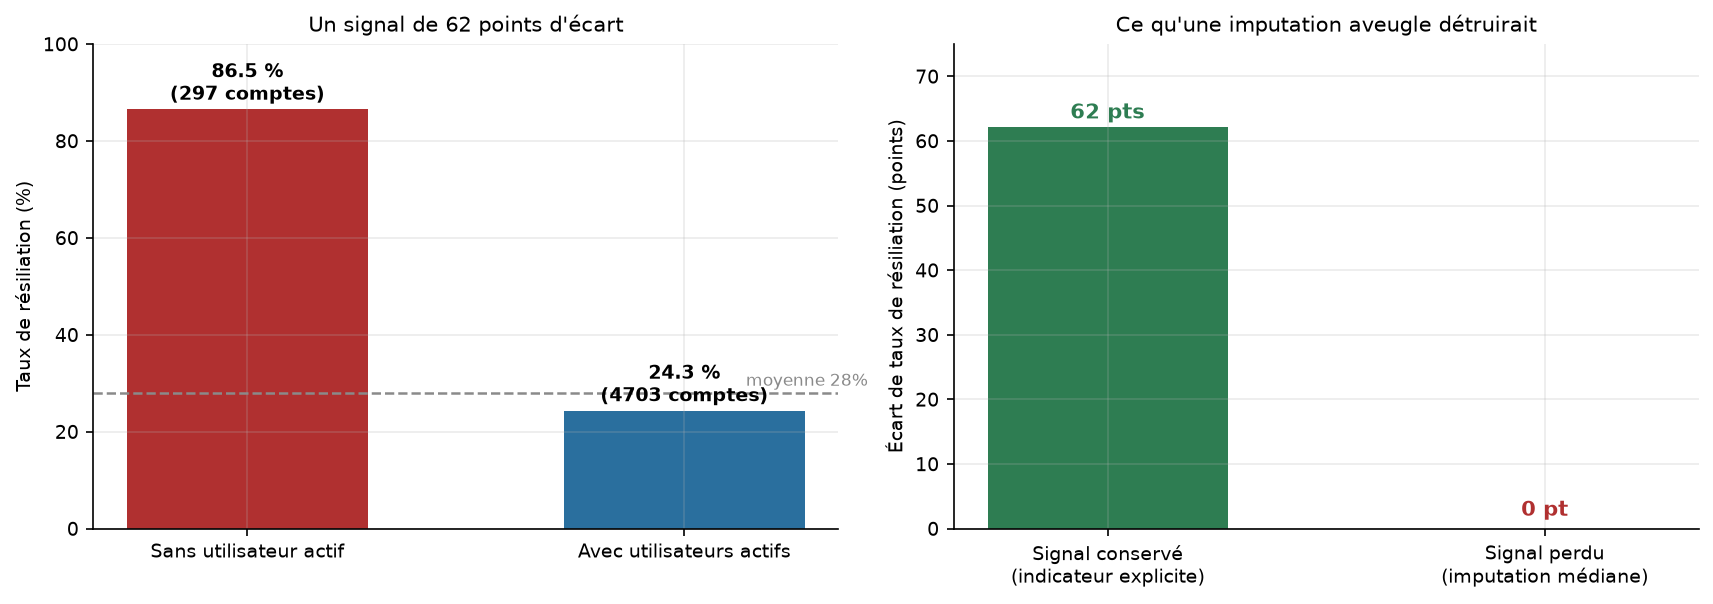

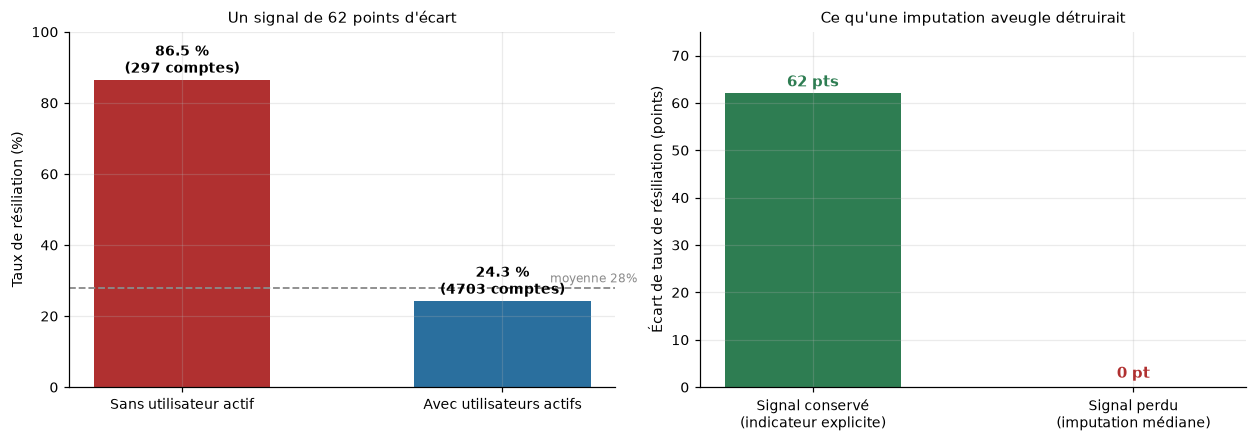

In [16]:
def tracer_compte_abandonne():
    """Drawn by `figure_en_cache`: hashing this source is what keeps the cache honest."""
    # --- Figure: what an imputation would erase ------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.1))

    groupes = ["Sans utilisateur actif", "Avec utilisateurs actifs"]
    taux = [cible[sans_actif].mean() * 100, cible[~sans_actif].mean() * 100]
    effectifs = [int(sans_actif.sum()), int((~sans_actif).sum())]

    barres = ax1.bar(groupes, taux, color=[PALETTE["accent"], PALETTE["principal"]], width=0.55)
    for barre, valeur, effectif in zip(barres, taux, effectifs):
        ax1.text(barre.get_x() + barre.get_width() / 2, valeur + 2,
                 f"{valeur:.1f} %\n({effectif} comptes)", ha="center", fontsize=9, fontweight="bold")
    ax1.axhline(float(cible.mean()) * 100, color=PALETTE["neutre"], ls="--", lw=1.2)
    ax1.text(1.42, float(cible.mean()) * 100 + 1.5, f"moyenne {cible.mean():.0%}",
             fontsize=8, color=PALETTE["neutre"], ha="right")
    ax1.set_ylabel("Taux de résiliation (%)")
    ax1.set_ylim(0, 100)
    ax1.set_title("Un signal de 62 points d'écart", fontsize=10)

    # Right panel: the signal, before and after a median imputation.
    ax2.bar(["Signal conservé\n(indicateur explicite)", "Signal perdu\n(imputation médiane)"],
            [62.2, 0], color=[PALETTE["ok"], PALETTE["accent"]], width=0.55)
    ax2.text(0, 63.5, "62 pts", ha="center", fontsize=10, fontweight="bold", color=PALETTE["ok"])
    ax2.text(1, 2, "0 pt", ha="center", fontsize=10, fontweight="bold", color=PALETTE["accent"])
    ax2.set_ylabel("Écart de taux de résiliation (points)")
    ax2.set_ylim(0, 75)
    ax2.set_title("Ce qu'une imputation aveugle détruirait", fontsize=10)

    plt.tight_layout()
    return fig
chemin, raison = figure_en_cache("03_compte_abandonne", signature_silver, tracer_compte_abandonne)
print(f"Figure « 03_compte_abandonne » : {raison}")
display(Image(filename=str(chemin)))

### La décision

Ces `NaN` **ne sont pas des données manquantes**. Ils encodent une situation métier
précise : un compte que l'entreprise facture et que plus personne n'utilise.

Imputer par la médiane remplacerait le signal le plus fort du jeu par la valeur d'un compte
ordinaire. Aucune métrique ne signalerait la perte — le modèle serait simplement moins bon,
sans que personne ne sache pourquoi.

Le pipeline déclare donc une variable explicite, `compte_sans_utilisateur_actif`, **avant**
de calculer les ratios. Le signal devient une variable, et une variable survit à
l'imputation. Elle est de surcroît lisible par un conseiller, ce qu'une valeur manquante
n'est pas.

In [17]:
from churn_saas.features.construction import ajouter_ratios_usage

afficher_source(ajouter_ratios_usage)

**Source — `churn_saas.features.construction.ajouter_ratios_usage`**

```python
def ajouter_ratios_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Add usage ratios, and the indicator their denominator hides.

    Ratios built here:

    - `taux_activation`      share of purchased seats actually used
    - `taux_couverture_fonc` share of plan features actually used
    - `usage_par_actif`      usage intensity per active user
    - `tickets_par_actif`    support pressure relative to account size

    **Plus one indicator that is not a ratio, and matters more than all of them.**
    Dividing by the number of active users yields NaN when that number is zero. Those NaN
    are not missing data: they encode a precise business situation - an account still
    being paid for that nobody uses.

    On this portfolio the situation covers 5.9% of accounts, which churn at 86.5% against
    24.3% for the rest. Leaving the signal inside a NaN would mean losing it at the first
    imputation, since a median would replace it with the value of an ordinary account.
    `compte_sans_utilisateur_actif` therefore states it explicitly (notebook 03, § 3).
    """
    out = df.copy()
    if "utilisateurs_actifs" in out.columns:
        # Declared before the ratios: the indicator explains the NaN they are about to
        # produce, and a reader meets the cause before the consequence.
        actifs = pd.to_numeric(out["utilisateurs_actifs"], errors="coerce")
        out["compte_sans_utilisateur_actif"] = (actifs == 0).astype("Int8")
    if {"utilisateurs_actifs", "sieges_souscrits"} <= set(out.columns):
        out["taux_activation"] = _ratio(out["utilisateurs_actifs"], out["sieges_souscrits"])
    if {"fonctionnalites_utilisees", "fonctionnalites_total"} <= set(out.columns):
        out["taux_couverture_fonc"] = _ratio(
            out["fonctionnalites_utilisees"], out["fonctionnalites_total"]
        )
    if {"heures_usage_30j", "utilisateurs_actifs"} <= set(out.columns):
        out["usage_par_actif"] = _ratio(out["heures_usage_30j"], out["utilisateurs_actifs"])
    if {"tickets_support_90j", "utilisateurs_actifs"} <= set(out.columns):
        out["tickets_par_actif"] = _ratio(out["tickets_support_90j"], out["utilisateurs_actifs"])
    return out

```

'def ajouter_ratios_usage(df: pd.DataFrame) -> pd.DataFrame:\n    """Add usage ratios, and the indicator their denominator hides.\n\n    Ratios built here:\n\n    - `taux_activation`      share of purchased seats actually used\n    - `taux_couverture_fonc` share of plan features actually used\n    - `usage_par_actif`      usage intensity per active user\n    - `tickets_par_actif`    support pressure relative to account size\n\n    **Plus one indicator that is not a ratio, and matters more than all of them.**\n    Dividing by the number of active users yields NaN when that number is zero. Those NaN\n    are not missing data: they encode a precise business situation - an account still\n    being paid for that nobody uses.\n\n    On this portfolio the situation covers 5.9% of accounts, which churn at 86.5% against\n    24.3% for the rest. Leaving the signal inside a NaN would mean losing it at the first\n    imputation, since a median would replace it with the value of an ordinary account

> **Journal de bord — retour de l'exploration vers les features.** La conclusion de la
> phase 2, « l'absence d'une valeur n'est pas un signal », reste vraie **pour les colonnes
> sources**. Elle ne se transpose pas aux colonnes construites, dont les manquants sont
> produits par le calcul lui-même. Généraliser aurait coûté le meilleur prédicteur du jeu.

## 3.5 Où se fait l'imputation, et pourquoi pas ici

Le niveau silver est défini comme « nettoyé, normalisé, lisible par un humain ». Un humain
qui lit un tableau ne veut pas de trous ; un modèle, si.

**Le pipeline n'impute donc pas.** L'imputation statistique est ajustée **à l'intérieur du
modèle**, sur les seuls plis d'entraînement. Remplir les valeurs avant la séparation
laisserait le jeu de test influencer les valeurs apprises — une fuite discrète, qu'aucune
métrique ne révèle.

Pour l'autre public, une fonction dédiée produit un silver lisible, explicitement disqualifié
pour l'apprentissage.

In [18]:
lisible = silver_lisible(silver)

afficher_tableau(
    pd.DataFrame(
        [
            {"jeu": "silver", "lignes": len(silver), "colonnes": silver.shape[1],
             "valeurs manquantes": int(silver.isna().sum().sum()),
             "usage": "modèle (imputation ajustée sur les plis d'entraînement)"},
            {"jeu": "silver lisible", "lignes": len(lisible), "colonnes": lisible.shape[1],
             "valeurs manquantes": int(lisible.isna().sum().sum()),
             "usage": "lecture humaine, restitution — jamais l'apprentissage"},
        ]
    ),
    "Deux consommateurs du silver, deux besoins opposés",
)

print("Les colonnes `_impute` signalent chaque valeur reconstruite :")
print("  " + ", ".join([c for c in lisible.columns if c.endswith("_impute")][:5]) + " …")

jeu,lignes,colonnes,valeurs manquantes,usage
silver,5000,39,6151,modèle (imputation ajustée sur les plis d'entraînement)
silver lisible,5000,51,0,"lecture humaine, restitution — jamais l'apprentissage"


Les colonnes `_impute` signalent chaque valeur reconstruite :
  secteur_impute, pays_impute, taux_adoption_pct_impute, heures_usage_30j_impute, nb_integrations_impute …


## 3.6 Le devenir de chaque colonne

In [19]:
transformations = table_transformations(resultat)
afficher_tableau(
    transformations.loc[transformations["devenir"] != "variable explicative"],
    "Colonnes qui ne deviennent pas des variables explicatives",
)
print(f"Variables explicatives retenues : "
      f"{int((transformations['devenir'] == 'variable explicative').sum())}")

colonne,origine,devenir,motif
client_id,source,retirée au gold,"identifiant — aucun pouvoir prédictif, risque de mémorisation"
date_souscription,source,retirée au gold,"date brute — encodée telle quelle, une catégorie par jour ; anciennete_mois porte déjà l'information"
groupe_experimentation,source,retirée au gold,artefact de process interne — pas une variable métier
commentaire_csm,source,retirée au gold,RGPD — texte libre susceptible de contenir des données personnelles
sante_compte_fin_periode,source,retirée au gold,fuite temporelle — information postérieure à la décision
valeur_vie_client_eur,source,retirée au gold,"cible secondaire — pondération de décision, jamais variable explicative"
churn,source,cible,—
fonctionnalites_incluses,construite,retirée au gold,doublon — copie exacte d'une colonne source (fonctionnalites_total)


Variables explicatives retenues : 31


## 3.7 Matérialiser les jeux produits

La chaîne calcule bronze, silver et gold en mémoire. Faut-il les écrire sur disque ?

**L'argument contre est solide.** La chaîne est déterministe — deux exécutions donnent la
même empreinte — et elle prend moins d'une seconde. Code et données sources étant tous deux
versionnés, le gold est recalculable à tout moment. L'écrire semble redondant.

**La faille de cet argument : il suppose le déterminisme au lieu de le vérifier.** Une
montée de version de pandas, un changement dans l'ordre d'une jointure, et le gold de
demain diffère de celui d'hier — sans que rien ne le signale. Le modèle serait entraîné sur
des données différentes de celles que sa fiche prétend décrire.

Le triangle de reproductibilité — code, données, modèle — avait un sommet manquant : rien ne
reliait une version de modèle au jeu exact qui l'avait produite.

In [20]:
from churn_saas.features import materialiser, table_materialisation, verifier_jeux_derives

manifeste = materialiser(resultat, version_donnees="v1.0")
afficher_tableau(
    table_materialisation(manifeste),
    "Instantanés écrits et enregistrés au manifeste",
)

Jeu,Fichier,Lignes,Colonnes,Taille,Empreinte du contenu,Version du code
silver,silver_v1.0_20261001.parquet,5000,39,276 Ko,30e080bf37dc64fd…,be57976
gold,gold_v1.0_20261001.parquet,5000,32,192 Ko,476ead59d4d91bc6…,be57976


### Ce qui est écrit, et où

| Jeu | Support | Versionné dans Git | Motif |
|---|---|---|---|
| **Bronze** | `data/raw/*.csv` | **Oui** | Sources de l'énoncé, 2 Mo, référence de tout le reste |
| **Silver** | `data/processed/*.parquet` | Non | Dérivé, recalculable depuis les sources et le code |
| **Gold** | `data/processed/*.parquet` | Non | Idem — c'est l'instantané d'entraînement |
| **Manifeste** | `data/manifeste_v1.0.json` | **Oui** | Petit, textuel, et c'est lui le contrat |

**Pourquoi Parquet et non CSV.** Le typage survit à l'aller-retour. Reparser les décimaux et
les dates au rechargement défairait exactement le travail de la phase 2.

**Pourquoi le bronze n'est pas réécrit.** Il existe déjà sous `data/raw/`. En produire une
seconde copie créerait un fichier susceptible de diverger de celui que le manifeste
empreinte : deux références au lieu d'une.

**Pourquoi ni silver ni gold en base relationnelle.** Une base ne versionne rien par
nature : une mise à jour écrase l'état précédent sans trace. C'est la conclusion du tableau
comparatif de la phase 2, et elle vaut toujours — la base reste le bon support pour les
**scores produits**, qu'on interroge, pas pour des données d'entraînement qu'on fige.

### Le contrôle avant entraînement

In [21]:
afficher_tableau(
    verifier_jeux_derives(resultat, manifeste),
    "Les instantanés correspondent-ils toujours à ce que la chaîne produit ?",
)

derives = manifeste["jeux_derives"]["jeux"]
print(f"Version du code ayant produit ces jeux : {derives['gold']['version_code']}")
print()
print("À exécuter avant tout entraînement. Un écart ne signifie pas forcément que le code")
print("est faux — une source peut avoir changé légitimement — mais il signifie que")
print("l'exécution ne reproduit plus ce que le manifeste décrit.")

jeu,fichier présent,empreinte attendue,empreinte constatée,conforme
silver,True,30e080bf37dc64fd…,30e080bf37dc64fd…,True
gold,True,476ead59d4d91bc6…,476ead59d4d91bc6…,True


Version du code ayant produit ces jeux : be57976

À exécuter avant tout entraînement. Un écart ne signifie pas forcément que le code
est faux — une source peut avoir changé légitimement — mais il signifie que
l'exécution ne reproduit plus ce que le manifeste décrit.


> **Journal de bord.** L'étape 4 du cycle de vie décrit en phase 2 — « instantané
> d'entraînement, jeu figé, horodaté et empreinté » — était restée déclarative. Elle est
> désormais effective, et la fiche modèle pourra référencer l'empreinte du gold ayant servi
> à l'entraînement. Une promesse tenue vaut mieux qu'une promesse formulée.

---

# 4. Le déséquilibre entre catégories

## 4.1 Le déséquilibre de la cible

In [22]:
afficher_tableau(desequilibre_cible(y), "Équilibre de la cible et ce qu'il implique")

mesure,valeur
Positifs (churn),1 400
Négatifs,3 600
Taux de positifs,28.0%
Ratio négatifs / positifs,2.6 : 1
Exactitude d'un modèle trivial,72.0% — d'où l'inutilité de cette métrique
Qualification,déséquilibre modéré


Figure « 03_cout_du_desequilibre » : inchangée


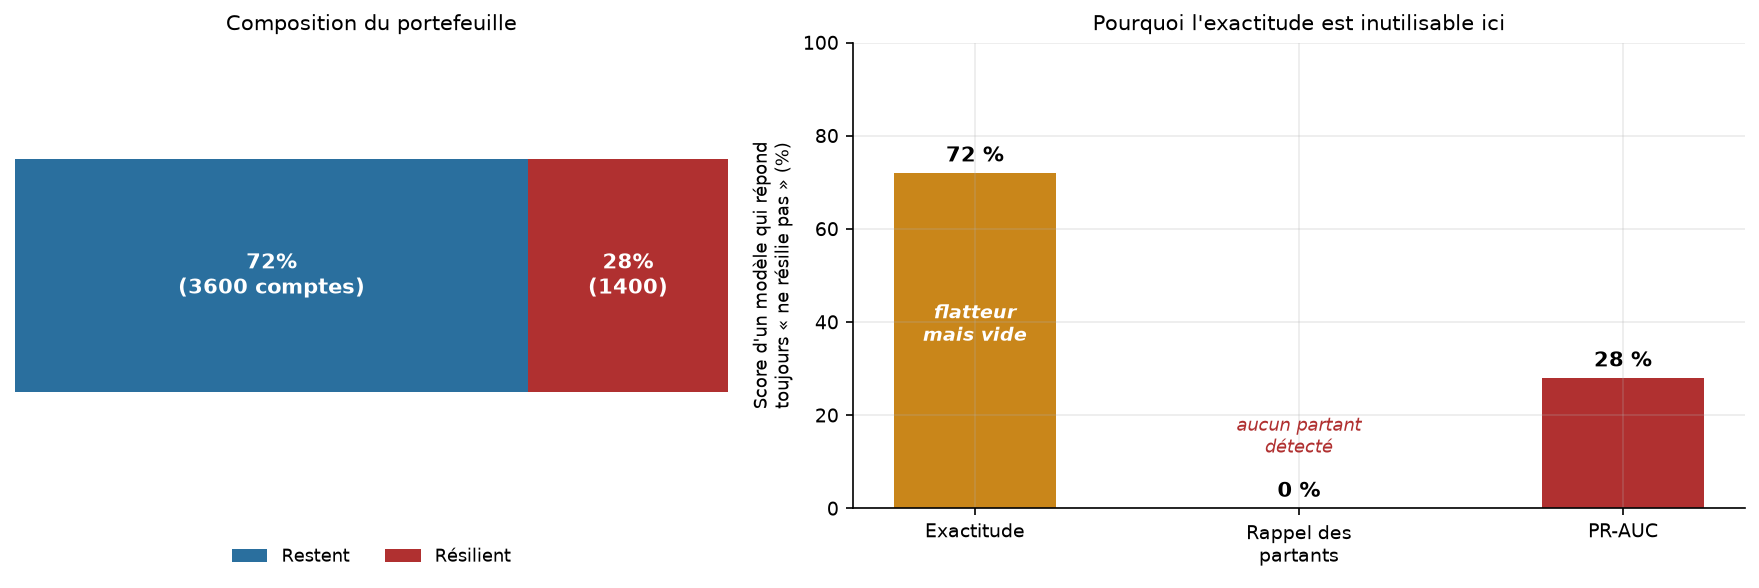

Un modèle trivial atteint 72% d'exactitude sans détecter un seul partant.
Le déséquilibre est modéré, non sévère : il disqualifie l'exactitude,
il ne justifie pas les techniques réservées aux événements rares.


In [23]:
def tracer_cout_du_desequilibre():
    """Drawn by `figure_en_cache`: hashing this source is what keeps the cache honest."""
    # --- Figure: what the imbalance costs, metric by metric ------------------------------
    # A pie chart of 28/72 would restate the table. What the reader needs is why the imbalance
    # matters, so the figure compares a trivial model to the task it is supposed to perform.
    positifs = int(y.astype(float).sum())
    negatifs = int(len(y) - positifs)
    taux = positifs / len(y)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.0),
                                   gridspec_kw={"width_ratios": [1, 1.25]})

    # Left: the balance itself, as proportions of the portfolio.
    ax1.barh([0], [negatifs], color=PALETTE["principal"], height=0.5, label="Restent")
    ax1.barh([0], [positifs], left=[negatifs], color=PALETTE["accent"], height=0.5,
             label="Résilient")
    ax1.text(negatifs / 2, 0, f"{1 - taux:.0%}\n({negatifs} comptes)", ha="center", va="center",
             color="white", fontsize=10, fontweight="bold")
    ax1.text(negatifs + positifs / 2, 0, f"{taux:.0%}\n({positifs})", ha="center", va="center",
             color="white", fontsize=10, fontweight="bold")
    ax1.set_xlim(0, len(y)); ax1.set_ylim(-0.5, 0.5)
    ax1.set_yticks([]); ax1.set_xticks([])
    ax1.set_title("Composition du portefeuille", fontsize=10)
    ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, fontsize=8.5)
    for bord in ax1.spines.values():
        bord.set_visible(False)
    ax1.grid(False)

    # Right: a model that always answers "stays" - excellent on one metric, useless on the task.
    metriques = ["Exactitude", "Rappel des\npartants", "PR-AUC"]
    trivial = [(1 - taux) * 100, 0.0, taux * 100]
    couleurs = [PALETTE["attention"], PALETTE["accent"], PALETTE["accent"]]

    barres = ax2.bar(metriques, trivial, color=couleurs, width=0.5)
    for barre, valeur in zip(barres, trivial):
        ax2.text(barre.get_x() + barre.get_width() / 2, valeur + 2.5, f"{valeur:.0f} %",
                 ha="center", fontsize=10, fontweight="bold")
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("Score d'un modèle qui répond\ntoujours « ne résilie pas » (%)", fontsize=8.5)
    ax2.set_title("Pourquoi l'exactitude est inutilisable ici", fontsize=10)
    # Inside the bar, in white: placed outside it the label would collide with the value.
    ax2.text(0, 36, "flatteur\nmais vide", ha="center", fontsize=9,
             color="white", style="italic", fontweight="bold")
    ax2.text(1, 12, "aucun partant\ndétecté", ha="center", fontsize=8.5,
             color=PALETTE["accent"], style="italic")

    plt.tight_layout()
    return fig
chemin, raison = figure_en_cache("03_cout_du_desequilibre", signature_cible, tracer_cout_du_desequilibre)
print(f"Figure « 03_cout_du_desequilibre » : {raison}")
display(Image(filename=str(chemin)))

taux_positifs = float(y.mean())
print(f"Un modèle trivial atteint {1 - taux_positifs:.0%} d'exactitude sans détecter un seul partant.")
print("Le déséquilibre est modéré, non sévère : il disqualifie l'exactitude,")
print("il ne justifie pas les techniques réservées aux événements rares.")

**Une nuance à tenir en soutenance.** Le déséquilibre est **modéré**, pas sévère. Il
disqualifie l'exactitude, mais il ne justifie pas le discours des problèmes à événement
rare, qui travaillent à 1 ou 2 % de positifs et appellent des techniques que nous n'avons
pas besoin d'employer.

Surjouer l'argument invite une correction. Le PR-AUC reste préférable au ROC-AUC, avec un
écart moins marqué qu'en classe rare — et sa valeur pour un modèle trivial, 28 %, donne le
plancher au-dessus duquel un vrai modèle doit se situer.

### Pourquoi le PR-AUC plutôt que le ROC-AUC

Les deux mesures résument la qualité d'un classement par un nombre, et toutes deux sont
légitimes. Elles ne réagissent pourtant pas de la même façon au déséquilibre, et c'est ce
qui tranche.

**Le ROC-AUC est insensible à la proportion de positifs.** C'est présenté comme une qualité
— la mesure reste comparable d'un jeu à l'autre — mais ici c'est un défaut : il ne reflète
pas le coût réel de travailler sur une classe minoritaire. **Le PR-AUC, lui, a pour plancher
le taux de positifs lui-même**, et se dégrade quand la classe se raréfie.

La figure ci-dessous le démontre par simulation. Un classement de qualité **identique** est
évalué sur des portefeuilles dont le taux de départ varie de 2 % à 50 %.

> **Ce que cette figure n'est pas.** Elle ne mesure aucun modèle de ce projet — aucun n'est
> encore entraîné à ce stade. Elle illustre une propriété des deux métriques, sur des scores
> simulés. Les vraies courbes ROC et précision-rappel viendront en phase d'évaluation.

Figure « 03_roc_contre_pr » : inchangée


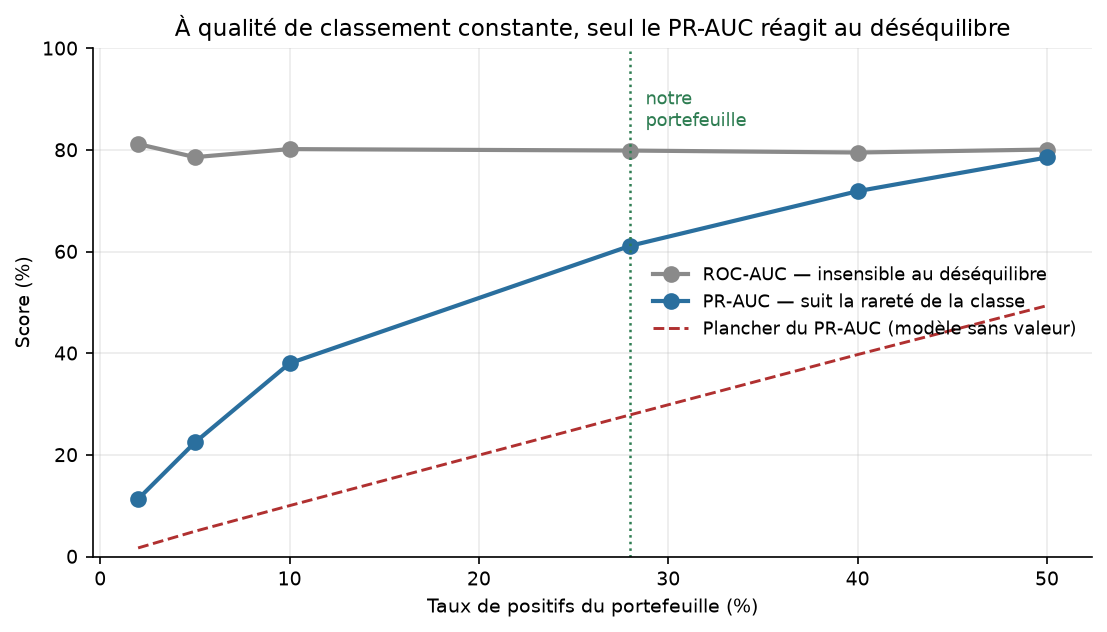

In [24]:
# --- Figure: how each metric reacts to the positive rate -----------------------------
from sklearn.metrics import average_precision_score, roc_auc_score



def tracer_roc_contre_pr():
    """Same ranking quality, varying positive rate: ROC stays, PR follows the base rate."""
    generateur = np.random.default_rng(42)
    taux_testes = [0.02, 0.05, 0.10, 0.28, 0.40, 0.50]
    n = 4000
    roc, pr, plancher = [], [], []

    for taux in taux_testes:
        verite = (generateur.random(n) < taux).astype(int)
        # One single discriminative power, reused at every rate: the separation between
        # the two score distributions never changes, so any difference in the metrics
        # comes from the balance alone.
        scores = generateur.normal(loc=verite * 1.2, scale=1.0)
        roc.append(roc_auc_score(verite, scores))
        pr.append(average_precision_score(verite, scores))
        plancher.append(verite.mean())

    fig, ax = plt.subplots(figsize=(8.6, 4.4))
    abscisses = [t * 100 for t in taux_testes]

    ax.plot(abscisses, [v * 100 for v in roc], "o-", color=PALETTE["neutre"], lw=2, ms=7,
            label="ROC-AUC — insensible au déséquilibre")
    ax.plot(abscisses, [v * 100 for v in pr], "o-", color=PALETTE["principal"], lw=2, ms=7,
            label="PR-AUC — suit la rareté de la classe")
    ax.plot(abscisses, [v * 100 for v in plancher], "--", color=PALETTE["accent"], lw=1.4,
            label="Plancher du PR-AUC (modèle sans valeur)")

    ax.axvline(28, color=PALETTE["ok"], lw=1.2, ls=":")
    ax.text(28.8, 92, "notre\nportefeuille", fontsize=8.5, color=PALETTE["ok"], va="top")

    ax.set_xlabel("Taux de positifs du portefeuille (%)")
    ax.set_ylabel("Score (%)")
    ax.set_ylim(0, 100)
    ax.set_title("À qualité de classement constante, seul le PR-AUC réagit au déséquilibre")
    ax.legend(fontsize=8.5, frameon=False, loc="center right")
    return fig
chemin, raison = figure_en_cache("03_roc_contre_pr", signature_cible, tracer_roc_contre_pr)
print(f"Figure « 03_roc_contre_pr » : {raison}")

display(Image(filename=str(chemin)))

**Lecture.** Le ROC-AUC reste plat : le même classement obtient le même score que la
classe représente 2 % ou 50 % du portefeuille. Le PR-AUC, lui, s'effondre quand la classe
se raréfie, en restant toujours au-dessus de son plancher — le taux de positifs.

**Ce que cela décide pour nous.** À 28 % de positifs, l'écart entre les deux mesures existe
sans être spectaculaire. Le PR-AUC est retenu pour la sélection du modèle parce qu'il
répond à la question du projet : *parmi les comptes que je signale, combien partent
vraiment ?* Le ROC-AUC répond à une autre question, qui intéresse moins une équipe
contrainte par sa capacité.

Le ROC-AUC reste reporté, car l'énoncé l'exige explicitement au titre de C4. Les deux
figurent donc au tableau de bord, avec le PR-AUC comme critère d'arbitrage.

La figure ci-dessous ne répète pas la table : elle montre **ce que le déséquilibre
coûte**. Un modèle répondant systématiquement « ne résilie pas » obtient 72 % d'exactitude
sans détecter un seul partant — flatteur et vide.

## 4.2 Le déséquilibre des variables catégorielles

In [25]:
categorielles = ["secteur", "pays", "taille_entreprise", "plan", "code_datacenter",
                 "couleur_theme_interface", "jour_souscription"]
afficher_tableau(
    desequilibre_categories(silver, categorielles, effectif_minimal=50),
    "Équilibre des variables catégorielles et modalités trop rares",
)

variable,modalités,plus fréquente,plus rare,rapport max/min,modalités < 50
secteur,7,Commerce (905),Public (398),2.3,0
pays,6,France (2691),Canada (384),7.0,0
taille_entreprise,4,PME (2068),GE (360),5.7,0
plan,4,Pro (1772),Enterprise (551),3.2,0
code_datacenter,4,eu-w1 (1264),eu-w3 (1231),1.0,0
couleur_theme_interface,5,clair (1074),vert (959),1.1,0
jour_souscription,7,mardi (754),dimanche (688),1.1,0


Figure « 03_categories_avant_apres » : données ou code de tracé modifiés


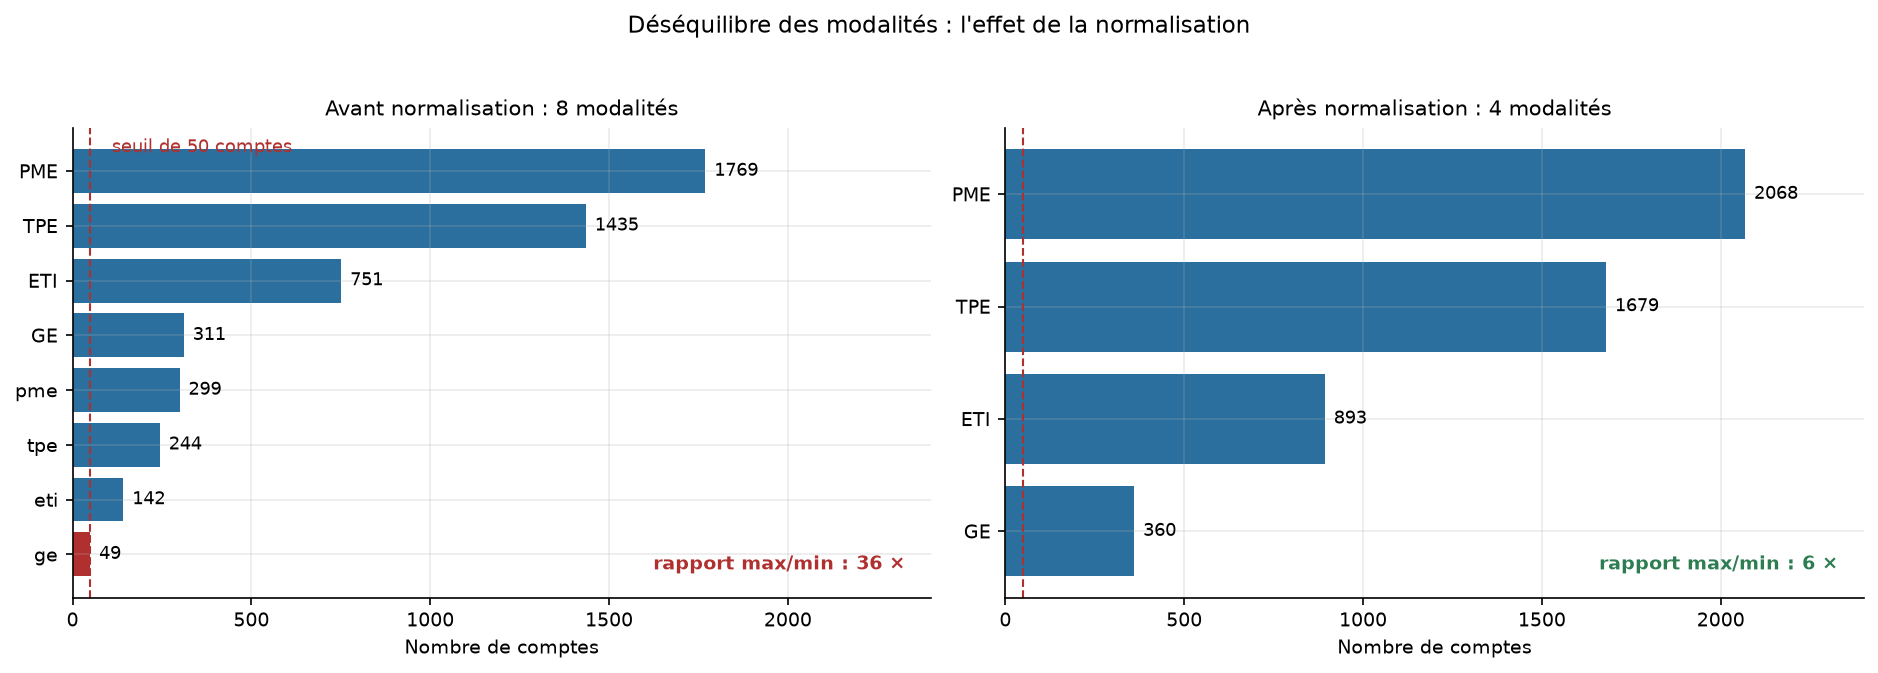

Avant : 8 modalités, la plus petite à 49 comptes (rapport 36×)
Après : 4 modalités, la plus petite à 360 comptes (rapport 6×)


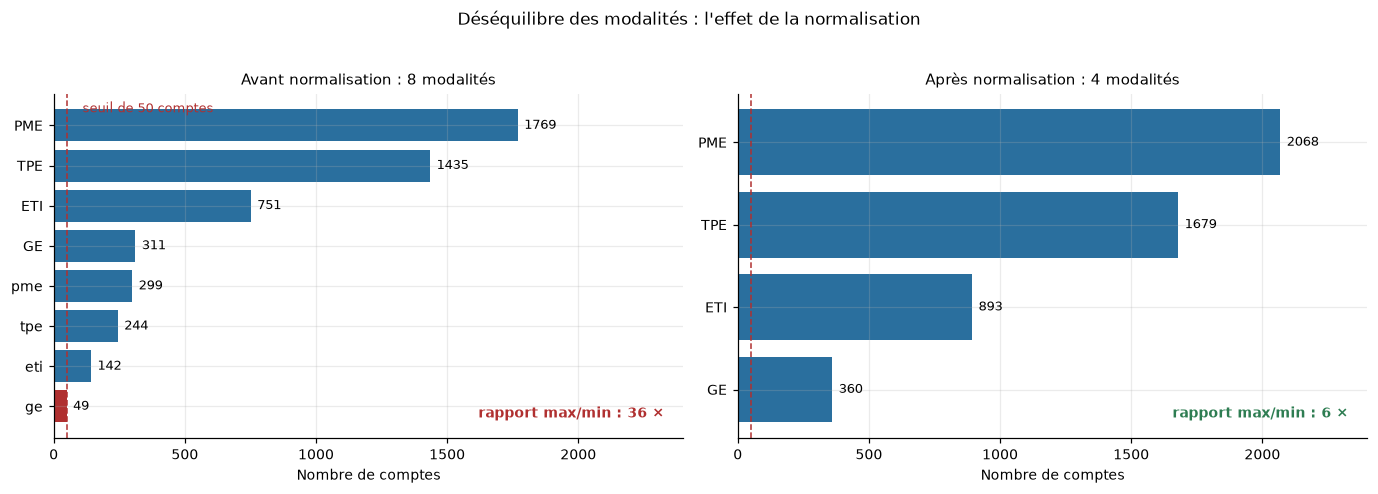

In [26]:
# Imported at cell level: both the drawing function and the comment below need it.
from churn_saas.donnees import construire_silver


def tracer_categories_avant_apres():
    """Drawn by `figure_en_cache`: hashing this source is what keeps the cache honest."""
    # --- Figure: category balance, before and after normalisation ------------------------
    # The same variable, read twice. The left panel is what the dataset looked like before the
    # case defect was fixed: it shows both the fragmentation and the imbalance it created.
    silver_brut = construire_silver(bronze, colonnes_categorielles=[])
    SEUIL_EFFECTIF = 50

    fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

    for ax, donnees, titre in [
        (axes[0], silver_brut, "Avant normalisation : 8 modalités"),
        (axes[1], silver, "Après normalisation : 4 modalités"),
    ]:
        effectifs = donnees["taille_entreprise"].value_counts().sort_values()
        couleurs = [
            PALETTE["accent"] if v < SEUIL_EFFECTIF else PALETTE["principal"] for v in effectifs
        ]
        ax.barh(range(len(effectifs)), effectifs.to_numpy(), color=couleurs)
        ax.set_yticks(range(len(effectifs)))
        ax.set_yticklabels(effectifs.index, fontsize=9)
        for i, v in enumerate(effectifs):
            ax.text(v + 25, i, str(v), va="center", fontsize=8.5)
        ax.axvline(SEUIL_EFFECTIF, color=PALETTE["accent"], ls="--", lw=1)
        ax.set_xlabel("Nombre de comptes")
        ax.set_title(titre, fontsize=10)
        ax.set_xlim(0, 2400)
        rapport = effectifs.max() / effectifs.min()
        ax.text(0.97, 0.06, f"rapport max/min : {rapport:.0f} ×", transform=ax.transAxes,
                ha="right", fontsize=9, fontweight="bold",
                color=PALETTE["accent"] if rapport > 10 else PALETTE["ok"])

    # Above the plot: at the bottom the label would overlap the smallest value.
    axes[0].text(SEUIL_EFFECTIF + 60, len(silver_brut["taille_entreprise"].unique()) - 0.4,
                 f"seuil de {SEUIL_EFFECTIF} comptes", fontsize=8.5,
                 color=PALETTE["accent"], va="top")
    fig.suptitle("Déséquilibre des modalités : l'effet de la normalisation", y=1.03)
    plt.tight_layout()
    return fig
chemin, raison = figure_en_cache("03_categories_avant_apres", signature_silver, tracer_categories_avant_apres)
print(f"Figure « 03_categories_avant_apres » : {raison}")
display(Image(filename=str(chemin)))

# Recomputed outside the drawing function: the comment below reads it, and the
# function's locals do not survive the call.
silver_brut = construire_silver(bronze, colonnes_categorielles=[])
avant = silver_brut["taille_entreprise"].value_counts()
apres = silver["taille_entreprise"].value_counts()
print(f"Avant : {len(avant)} modalités, la plus petite à {avant.min()} comptes "
      f"(rapport {avant.max() / avant.min():.0f}×)")
print(f"Après : {len(apres)} modalités, la plus petite à {apres.min()} comptes "
      f"(rapport {apres.max() / apres.min():.0f}×)")

**Un défaut découvert en traçant cette table.** Les premières exécutions affichaient
huit tailles d'entreprise pour quatre réelles, vingt-et-un secteurs pour sept, douze
formules pour quatre : `TPE` et `tpe`, `STARTER` et `Starter` et `starter` étaient comptés
séparément.

La normalisation de la casse n'était appliquée qu'à la **clé de jointure**, sous forme d'une
colonne temporaire. La jointure fonctionnait donc, tandis que les valeurs stockées
conservaient toutes leurs orthographes. L'encodage aurait transformé chaque variante en
colonne distincte : le modèle aurait vu plusieurs catégories rares là où le métier en a une
seule, aurait réparti le signal entre elles, et toute lecture d'importance serait devenue
trompeuse.

Corrigé dans le niveau silver, qui normalise désormais les **valeurs** et pas seulement la
clé. L'étiquette retenue est l'orthographe la plus fréquente — `TPE` reste `TPE`, et non
`tpe`, car ce tableau est lu par un humain.

La figure suivante lit la même variable deux fois : avant et après normalisation. Elle
montre d'un coup la fragmentation et le déséquilibre qu'elle créait.

**Ce que la table sert à décider.** Une modalité portant une poignée de comptes produit une
estimation instable, que l'encodage transformerait en colonne mémorisable par le modèle.
Après normalisation, aucune modalité ne tombe sous le seuil : le regroupement n'est pas
nécessaire.

Le préprocesseur applique néanmoins `min_frequency=0.01`, qui regroupe automatiquement les
modalités sous 1 %. C'est une précaution pour la production, où une nouvelle valeur peut
apparaître.

## 4.3 Le risque est-il également réparti ?

Figure « 03_risque_par_segment » : données ou code de tracé modifiés


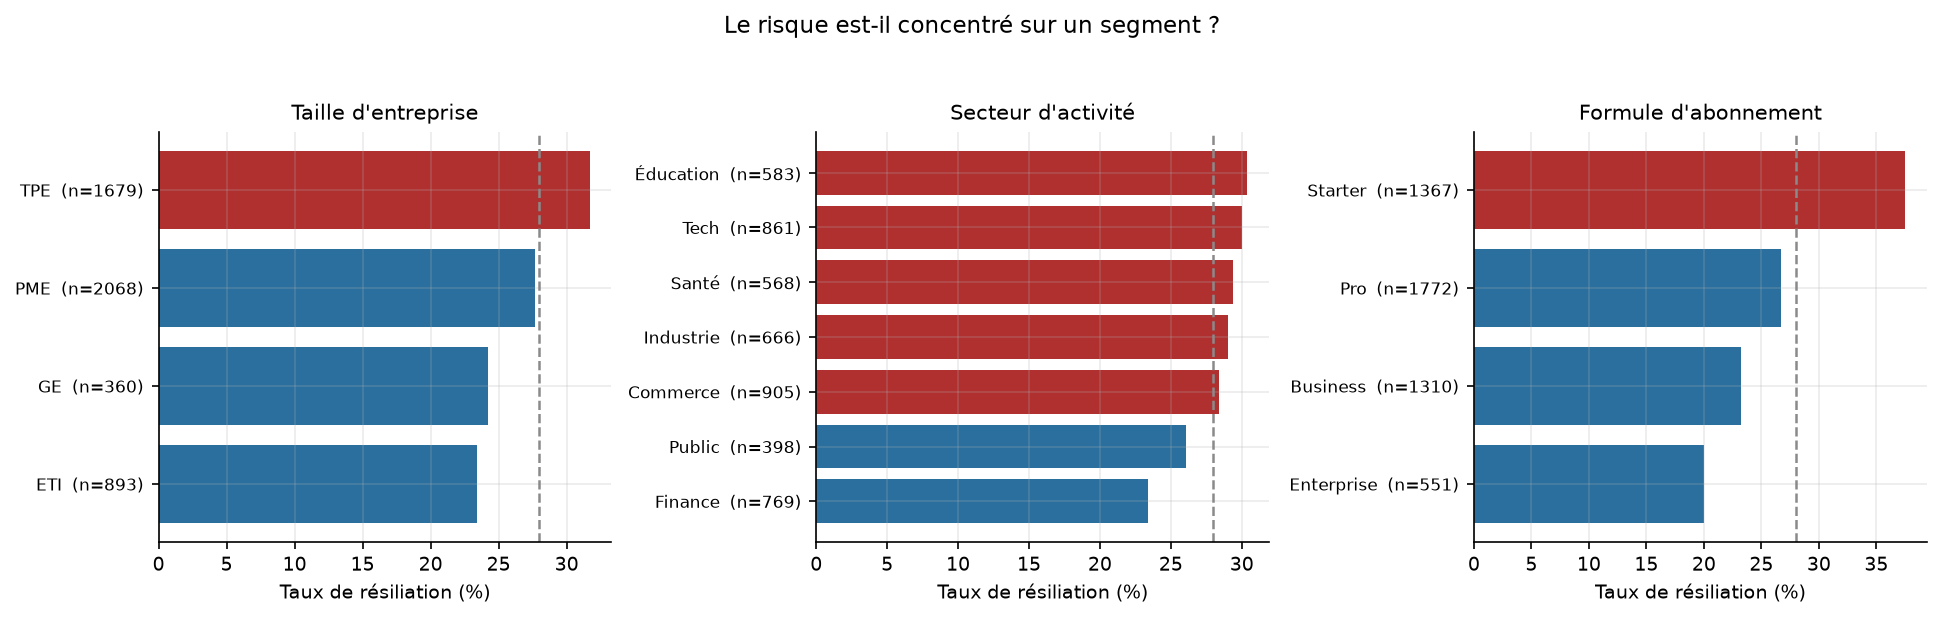

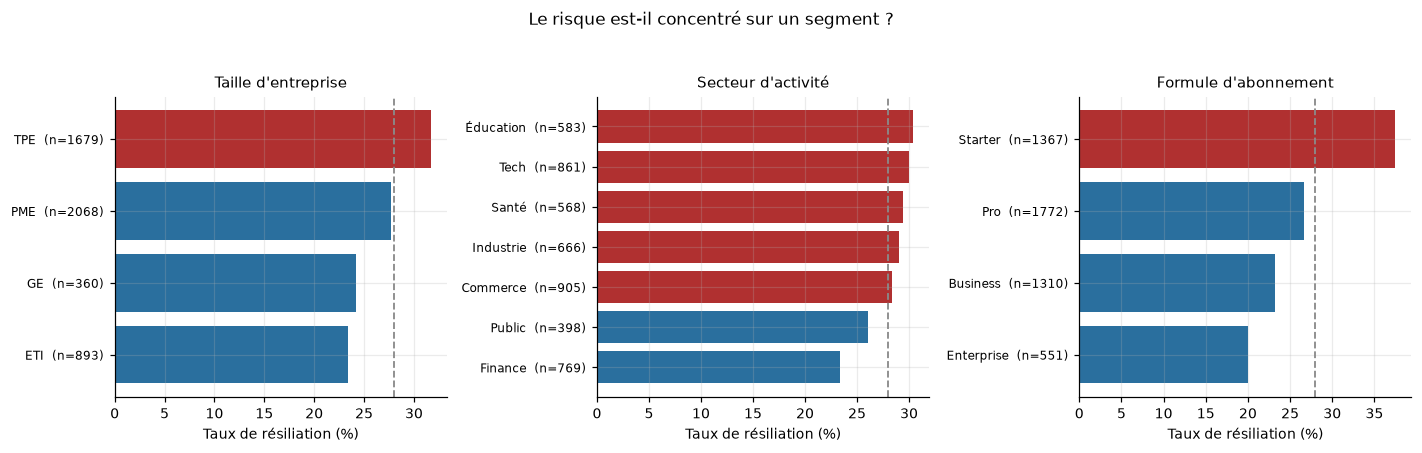

In [27]:
def tracer_risque_par_segment():
    """Drawn by `figure_en_cache`: hashing this source is what keeps the cache honest."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
    taux_global = float(y.mean())

    for ax, colonne, titre in zip(
        axes,
        ["taille_entreprise", "secteur", "plan"],
        ["Taille d'entreprise", "Secteur d'activité", "Formule d'abonnement"],
    ):
        profil = taux_cible_par_segment(silver, colonne, "churn").sort_values("taux cible (%)")
        couleurs = [
            PALETTE["accent"] if t > taux_global * 100 else PALETTE["principal"]
            for t in profil["taux cible (%)"]
        ]
        ax.barh(range(len(profil)), profil["taux cible (%)"], color=couleurs)
        ax.set_yticks(range(len(profil)))
        ax.set_yticklabels(
            [f"{m}  (n={e})" for m, e in zip(profil["modalité"], profil["effectif"])], fontsize=8
        )
        ax.axvline(taux_global * 100, color=PALETTE["neutre"], ls="--", lw=1.2)
        ax.set_xlabel("Taux de résiliation (%)")
        ax.set_title(titre, fontsize=10)

    fig.suptitle("Le risque est-il concentré sur un segment ?", y=1.04)
    plt.tight_layout()
    return fig
chemin, raison = figure_en_cache("03_risque_par_segment", signature_silver, tracer_risque_par_segment)
print(f"Figure « 03_risque_par_segment » : {raison}")
display(Image(filename=str(chemin)))

**Lecture.** Les écarts restent contenus et aucun segment ne concentre le risque. Une règle
métier simple du type « surveiller le secteur X » ne suffirait donc pas : c'est ce qui
justifie de construire un modèle plutôt qu'une segmentation.

Ces variables restent sous surveillance pour l'analyse d'équité prévue en phase
d'évaluation — un écart modeste dans les données brutes peut être amplifié par un modèle.

---

# 5. Corrélations et tendances

## 5.1 Ce qui sépare la cible

In [28]:
correlations = correlations_cible(X, y)
afficher_tableau(correlations.head(14), "Variables les plus corrélées à la résiliation")

variable,corrélation,sens,notable
nb_integrations,-0.371,diminue le risque,True
derniere_connexion_jours,0.353,augmente le risque,True
compte_sans_utilisateur_actif,0.328,augmente le risque,True
anciennete_mois,-0.325,diminue le risque,True
taux_activation,-0.306,diminue le risque,True
taux_adoption_pct,-0.304,diminue le risque,True
retards_paiement_12m,0.303,augmente le risque,True
csat,-0.279,diminue le risque,True
tickets_support_90j,0.270,augmente le risque,True
taux_couverture_fonc,-0.261,diminue le risque,True


Figure « 03_correlations » : données ou code de tracé modifiés


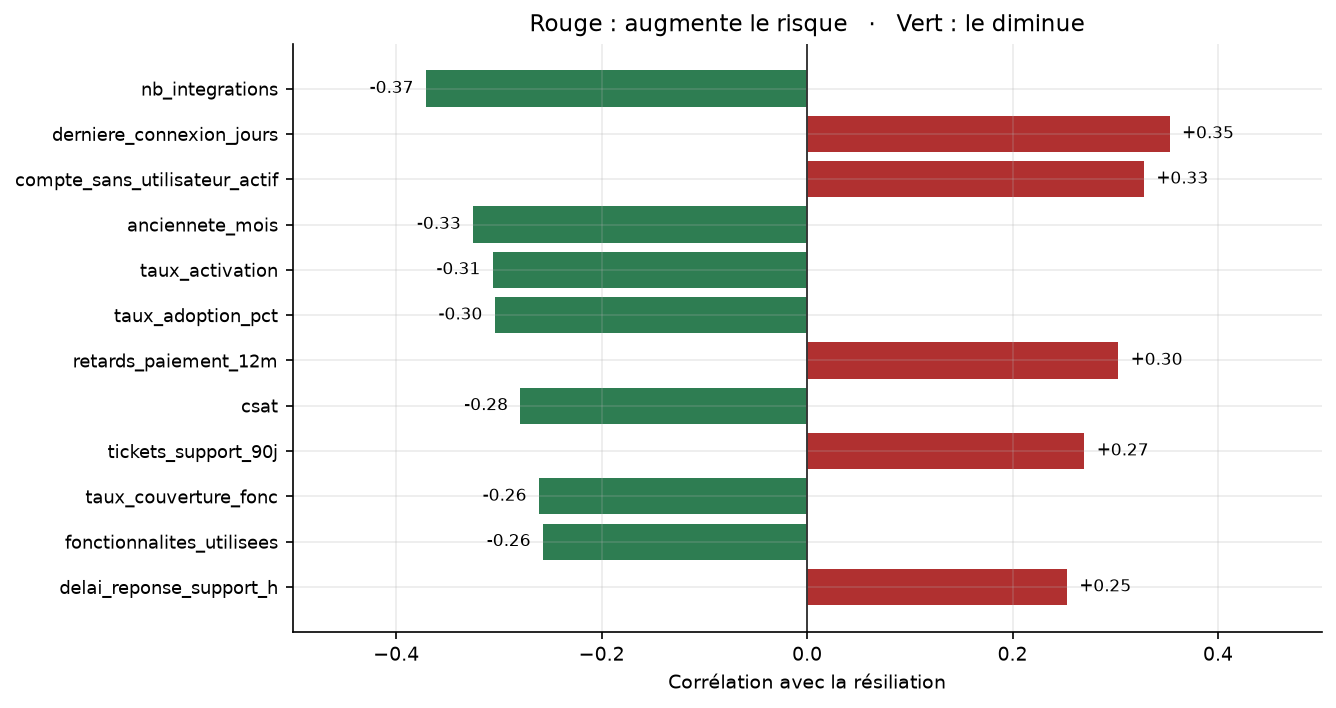

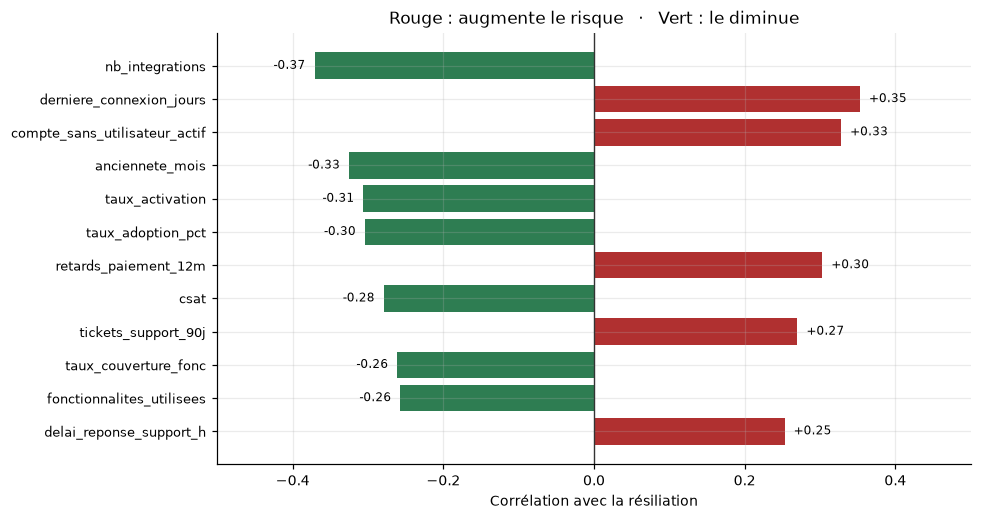

In [29]:
def tracer_correlations():
    """Drawn by `figure_en_cache`: hashing this source is what keeps the cache honest."""
    # --- Figure: correlation with the target, strongest first ----------------------------
    notables = correlations.loc[correlations["notable"]].head(12).iloc[::-1]
    couleurs = [PALETTE["accent"] if c > 0 else PALETTE["ok"] for c in notables["corrélation"]]

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.barh(range(len(notables)), notables["corrélation"], color=couleurs)
    ax.set_yticks(range(len(notables)))
    ax.set_yticklabels(notables["variable"], fontsize=8.5)
    ax.axvline(0, color="#333333", lw=0.9)
    for i, v in enumerate(notables["corrélation"]):
        ax.text(v + (0.012 if v > 0 else -0.012), i, f"{v:+.2f}",
                va="center", ha="left" if v > 0 else "right", fontsize=8)
    ax.set_xlabel("Corrélation avec la résiliation")
    ax.set_title("Rouge : augmente le risque   ·   Vert : le diminue")
    marge = float(notables["corrélation"].abs().max()) * 1.35
    ax.set_xlim(-marge, marge)
    plt.tight_layout()
    return fig
chemin, raison = figure_en_cache("03_correlations", signature_gold, tracer_correlations)
print(f"Figure « 03_correlations » : {raison}")
display(Image(filename=str(chemin)))

**Deux précautions accompagnent cette table, et elles comptent autant que la table.**

Une corrélation est **linéaire et bivariée**. Une variable qui ne compte qu'en combinaison
avec une autre apparaît ici proche de zéro. Une corrélation faible n'est donc **pas** une
raison d'écarter une variable — la section suivante le montre sur un cas concret.

Et une corrélation **très élevée** sur un problème de churn n'est pas un succès mais un
symptôme : c'est à cela que ressemble une fuite de données. Aucune variable du jeu gold ne
dépasse le seuil d'alerte, ce qui confirme que l'exclusion opérée en phase 2 a fonctionné.

## 5.2 Les variables redondantes

In [30]:
paires = correlations_entre_variables(X, seuil=0.80)
if paires.empty:
    print("Aucune paire de variables au-delà de 0,80 : pas de redondance forte.")
else:
    afficher_tableau(paires, "Paires de variables disant presque la même chose")

variable A,variable B,corrélation
taux_adoption_pct,taux_activation,1.000
fonctionnalites_total,prix_mensuel_par_siege_eur,0.994
prix_mensuel_par_siege_eur,quota_stockage_go,0.948
sieges_souscrits,revenu_mensuel_recurrent_eur,0.915
fonctionnalites_total,sla_reponse_h,0.909
fonctionnalites_total,quota_stockage_go,0.909
connexions_30j,heures_usage_30j,0.900
prix_mensuel_par_siege_eur,sla_reponse_h,0.861
sieges_souscrits,utilisateurs_actifs,0.851
derniere_connexion_jours,compte_sans_utilisateur_actif,0.805


**Pourquoi la redondance dérange, même sans nuire à la performance.** Un ensemble d'arbres
s'en accommode. Mais deux variables équivalentes se partagent le crédit dans toute lecture
d'importance : chacune paraît deux fois moins utile qu'elle ne l'est, et l'interprétation
transmise au conseiller devient trompeuse.

## 5.3 Les tendances non monotones

La corrélation résume une relation par un nombre. Ce nombre suppose la relation monotone —
si elle ne l'est pas, il la sous-estime, et un modèle linéaire la manquera entièrement.

Figure « 03_tendances_par_tranche » : données ou code de tracé modifiés


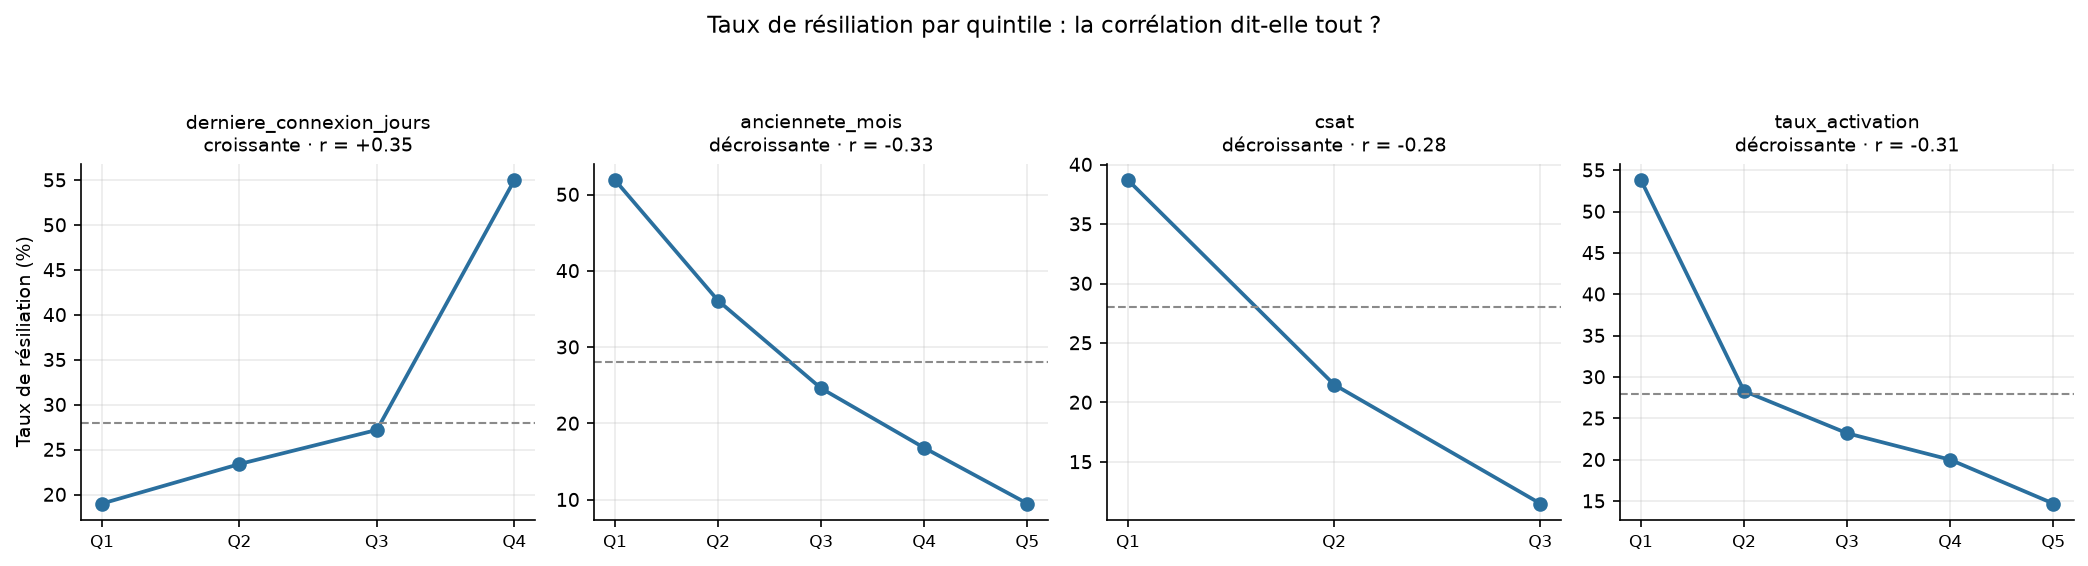

variable,forme,corrélation,amplitude (points)
derniere_connexion_jours,croissante,0.353,36.0
anciennete_mois,décroissante,-0.325,42.4
csat,décroissante,-0.279,27.2
taux_activation,décroissante,-0.306,39.1


In [31]:
def tracer_tendances_par_tranche():
    """Drawn by `figure_en_cache`: hashing this source is what keeps the cache honest."""
    candidates = ["derniere_connexion_jours", "anciennete_mois", "csat", "taux_activation"]

    fig, axes = plt.subplots(1, len(candidates), figsize=(14, 3.5))
    resumes = []

    for ax, colonne in zip(axes, candidates):
        profil = tendance_par_tranche(silver, colonne, "churn", n_tranches=5)
        forme = monotonie(profil)
        correlation = correlations.loc[correlations["variable"] == colonne, "corrélation"]
        correlation = float(correlation.iloc[0]) if len(correlation) else float("nan")

        couleur = PALETTE["attention"] if forme == "non monotone" else PALETTE["principal"]
        ax.plot(range(len(profil)), profil["taux (%)"], "o-", color=couleur, lw=1.8, ms=6)
        ax.axhline(taux_global * 100, color=PALETTE["neutre"], ls="--", lw=1)
        ax.set_xticks(range(len(profil)))
        ax.set_xticklabels([f"Q{i + 1}" for i in range(len(profil))], fontsize=8)
        ax.set_title(f"{colonne}\n{forme} · r = {correlation:+.2f}", fontsize=9)
        if ax is axes[0]:
            ax.set_ylabel("Taux de résiliation (%)")
        resumes.append({"variable": colonne, "forme": forme, "corrélation": round(correlation, 3),
                        "amplitude (points)": round(float(profil["taux (%)"].max()
                                                          - profil["taux (%)"].min()), 1)})

    fig.suptitle("Taux de résiliation par quintile : la corrélation dit-elle tout ?", y=1.06)
    plt.tight_layout()
    return fig, resumes
# The cache stores the figure; the summary table is recomputed, being cheap and
# needed by the table below.
def tracer_seulement():
    return tracer_tendances_par_tranche()[0]


chemin, raison = figure_en_cache(
    "03_tendances_par_tranche", signature_silver, tracer_seulement
)
_, resumes = tracer_tendances_par_tranche()
plt.close('all')
print(f"Figure « 03_tendances_par_tranche » : {raison}")
display(Image(filename=str(chemin)))

afficher_tableau(pd.DataFrame(resumes), "Forme de la relation, au-delà du coefficient")

**Ce que la comparaison révèle.** Une variable peut afficher une corrélation modeste et
séparer nettement les quintiles extrêmes. L'amplitude entre le premier et le dernier
quintile est souvent plus parlante que le coefficient, et c'est elle qu'un conseiller
comprendra.

**Conséquence pour la modélisation.** Les relations non monotones sont hors de portée d'une
régression logistique sans transformation préalable, alors qu'un ensemble d'arbres les capte
naturellement. C'est un argument pour comparer les deux familles plutôt que de trancher
d'avance — argument issu de l'exploration, non d'une préférence.

---

# 6. Synthèse de la phase

## 6.1 Décisions arrêtées, par activité

Les décisions sont rangées par **activité de préparation** plutôt que par ordre de
découverte. Un lecteur cherchant ce qui a été décidé sur l'imputation trouve tout au même
endroit, et une rubrique vide serait un manque visible.

In [32]:
# Decisions grouped by the activity they belong to, not by order of discovery.
# A reader looking for "what did we decide about imputation" finds it in one place, and
# an empty category would be a gap worth noticing.
decisions = pd.DataFrame([
    # --- Nettoyage et normalisation ---------------------------------------------------
    ("Nettoyage · normalisation", "Uniformiser la casse des modalités",
     "8 tailles pour 4 réelles, 21 secteurs pour 7 : l'encodage aurait fabriqué des "
     "catégories rares et réparti le signal entre elles", "§ 4.2"),
    ("Nettoyage · normalisation", "Supprimer les doublons stricts",
     "Aucun doublon sur la clé métier : la suppression ne perd aucune information", "§ 2.1"),
    ("Nettoyage · normalisation", "Normaliser la clé avant jointure",
     "Sans elle, 2 302 lignes sur 5 035 ne seraient pas appariées, sans erreur", "§ 3.3"),

    # --- Imputation -------------------------------------------------------------------
    ("Imputation", "Imputation statistique légitime sur les colonnes source",
     "Deux lectures concordantes : écart ≤ 4,5 points et aucune cause structurelle", "§ 2.3"),
    ("Imputation", "Imputer par la médiane, jamais par la moyenne",
     "Moyenne > 5 × médiane sur le MRR : la moyenne importerait l'asymétrie", "§ 2.4"),
    ("Imputation", "N'imputer nulle part dans le pipeline",
     "Imputer avant la séparation laisse le jeu de test influencer l'apprentissage ; "
     "l'imputation est ajustée sur les seuls plis d'entraînement", "§ 3.5"),
    ("Imputation", "Ne pas imputer les NaN des ratios",
     "Ils encodent un compte abandonné : la médiane y remplacerait 62 points d'écart de "
     "risque par la valeur d'un compte ordinaire", "§ 3.4"),

    # --- Variables dérivées -----------------------------------------------------------
    ("Variables dérivées", "Déclarer `compte_sans_utilisateur_actif`",
     "Un NaN ne survit à aucune imputation, une variable si — et un conseiller peut la lire",
     "§ 3.4"),
    ("Variables dérivées", "Construire les ratios d'usage",
     "Un ratio ramène l'usage à la taille du compte : « 2 fonctionnalités sur 10 » répond "
     "à une question qu'aucun des deux nombres ne pose", "§ 3.4"),
    ("Variables dérivées", "Rendre l'enrichissement désactivable",
     "La contribution du feature engineering doit pouvoir être comparée, pas affirmée",
     "§ 3.1"),

    # --- Valeurs extrêmes -------------------------------------------------------------
    ("Valeurs extrêmes", "Conserver les valeurs extrêmes",
     "Les bornes de Tukey retireraient un compte sur huit et la moitié du revenu : ce ne "
     "sont pas des anomalies, ce sont les comptes stratégiques", "§ 2.4"),

    ("Architecture des données", "Matérialiser silver et gold en Parquet",
     "Le déterminisme doit être vérifié, pas supposé : une empreinte enregistrée détecte "
     "une dérive qu'aucune métrique ne signalerait", "§ 3.7"),
    ("Architecture des données", "Ne pas versionner les instantanés dans Git",
     "Dérivés et recalculables : un diff binaire à chaque règle de nettoyage modifiée, "
     "pour une information déjà contenue dans les sources et le code", "§ 3.7"),
    ("Architecture des données", "Ni silver ni gold en base relationnelle",
     "Une base ne versionne rien : une mise à jour écrase l'état précédent sans trace",
     "§ 3.7"),

    # --- Catégories et déséquilibre ---------------------------------------------------
    ("Catégories · déséquilibre", "Qualifier le déséquilibre de modéré",
     "28 % de positifs : l'exactitude est inutilisable, le discours du cas rare serait faux",
     "§ 4.1"),
    ("Catégories · déséquilibre", "Ne regrouper aucune modalité",
     "Aucune sous 50 comptes après normalisation ; `min_frequency` couvre le cas en "
     "production", "§ 4.2"),
    ("Catégories · déséquilibre", "Surveiller les variables indirectes",
     "Pays, secteur et taille restent sous surveillance pour l'analyse d'équité", "§ 4.3"),

    # --- Architecture des données -----------------------------------------------------
    ("Architecture des données", "Séparer un silver lisible",
     "Deux consommateurs, deux besoins opposés : un humain veut des valeurs, un modèle "
     "veut des trous", "§ 3.5"),
    ("Architecture des données", "Journaliser chaque étape du pipeline",
     "Une transformation que personne ne peut chiffrer est une transformation que "
     "personne ne peut défendre", "§ 3.1"),

    # --- Orientation de la modélisation -----------------------------------------------
    ("Orientation modélisation", "Comparer deux familles de modèles",
     "Des relations non monotones échappent à un modèle linéaire sans transformation",
     "§ 5.3"),
    ("Orientation modélisation", "Ne pas écarter une variable sur sa seule corrélation",
     "Une corrélation est linéaire et bivariée : une variable utile en combinaison "
     "apparaît proche de zéro", "§ 5.1"),
], columns=["Activité", "Décision", "Fondement", "Renvoi"])

afficher_tableau(decisions, "Décisions de l'exploration, par activité")

print(f"{len(decisions)} décisions réparties sur "
      f"{decisions['Activité'].nunique()} activités.")

Activité,Décision,Fondement,Renvoi
Nettoyage · normalisation,Uniformiser la casse des modalités,"8 tailles pour 4 réelles, 21 secteurs pour 7 : l'encodage aurait fabriqué des catégories rares et réparti le signal entre elles",§ 4.2
Nettoyage · normalisation,Supprimer les doublons stricts,Aucun doublon sur la clé métier : la suppression ne perd aucune information,§ 2.1
Nettoyage · normalisation,Normaliser la clé avant jointure,"Sans elle, 2 302 lignes sur 5 035 ne seraient pas appariées, sans erreur",§ 3.3
Imputation,Imputation statistique légitime sur les colonnes source,"Deux lectures concordantes : écart ≤ 4,5 points et aucune cause structurelle",§ 2.3
Imputation,"Imputer par la médiane, jamais par la moyenne",Moyenne > 5 × médiane sur le MRR : la moyenne importerait l'asymétrie,§ 2.4
Imputation,N'imputer nulle part dans le pipeline,Imputer avant la séparation laisse le jeu de test influencer l'apprentissage ; l'imputation est ajustée sur les seuls plis d'entraînement,§ 3.5
Imputation,Ne pas imputer les NaN des ratios,Ils encodent un compte abandonné : la médiane y remplacerait 62 points d'écart de risque par la valeur d'un compte ordinaire,§ 3.4
Variables dérivées,Déclarer `compte_sans_utilisateur_actif`,"Un NaN ne survit à aucune imputation, une variable si — et un conseiller peut la lire",§ 3.4
Variables dérivées,Construire les ratios d'usage,Un ratio ramène l'usage à la taille du compte : « 2 fonctionnalités sur 10 » répond à une question qu'aucun des deux nombres ne pose,§ 3.4
Variables dérivées,Rendre l'enrichissement désactivable,"La contribution du feature engineering doit pouvoir être comparée, pas affirmée",§ 3.1


21 décisions réparties sur 7 activités.


## 6.2 Les figures produites

Chaque figure est enregistrée sous `reports/figures/`, en PNG et en SVG. Les documents du
projet s'y réfèrent par leur nom, sans chemin écrit en dur, et sans capture d'écran.

Une figure n'est retracée que si les **données** ou le **code de tracé** ont changé. La clé
du cache combine l'empreinte des données et le source de la fonction qui dessine : modifier
une couleur ou un seuil invalide donc l'image d'elle-même, sans qu'il faille penser à
incrémenter un numéro de version — c'est précisément le mode de défaillance des caches
fondés sur une version déclarée.

## 6.3 Ce que l'exploration change pour la suite

| Phase suivante | Ce qui est déjà tranché |
|---|---|
| Préparation | Médiane, pas de retrait d'extrêmes, indicateur d'abandon déclaré |
| Modélisation | Deux familles à comparer, PR-AUC comme critère |
| Évaluation | Variables indirectes sous surveillance pour l'analyse d'équité |

## 6.3 Correspondance avec le livrable de certification

| Élément de ce carnet | Section du notebook principal | Compétence |
|---|---|---|
| § 2 — Profilage, manquants, distributions | 5 et 6 | C3 |
| § 3 — Chaîne bronze → silver → gold | 7 | C3 |
| § 3.4 — Indicateur d'abandon | 7 (feature engineering) | C3, C5 |
| § 4 — Déséquilibre | 6 et 8 | C3, C4 |
| § 5 — Corrélations et tendances | 6 | C3 |
| § 6 — Décisions | 7 (journal de bord) | C3 |

In [33]:
afficher_tableau(inventaire_figures(), "Figures enregistrées, réutilisables dans les documents")

figure,phase,formats,taille
03_categories_avant_apres,03,"png, svg",67 Ko
03_completude,03,"png, svg",66 Ko
03_compte_abandonne,03,"png, svg",65 Ko
03_correlations,03,"png, svg",59 Ko
03_cout_du_desequilibre,03,"png, svg",59 Ko
03_distributions,03,"png, svg",61 Ko
03_risque_par_segment,03,"png, svg",73 Ko
03_roc_contre_pr,03,"png, svg",68 Ko
03_tendances_par_tranche,03,"png, svg",104 Ko
